# Sen1Floods11 Satellite Flood Dataset Exploration

## Explainable AI Analysis of Satellite Flood Imagery

This notebook performs the initial exploration of the Sen1Floods11 dataset for a research study on Explainable AI (XAI) for flood analysis.

The initial objective is to:

- Understand Sentinel-1 satellite flood imagery.
- Inspect the ground-truth flood labels.
- Visualize the satellite bands and flood mask.
- Calculate basic flood statistics.
- Prepare the dataset for a later deep learning and Explainable AI pipeline.

### Planned Research Pipeline

Satellite Imagery
→ Deep Learning Model
→ Flood Prediction
→ Grad-CAM
→ SHAP
→ Explainable AI Analysis

## 1. Dataset Overview

Sen1Floods11 is a georeferenced dataset developed for training and evaluating deep learning models for flood mapping using Sentinel-1 satellite imagery.

The dataset provides Sentinel-1 Synthetic Aperture Radar (SAR) imagery together with corresponding ground-truth flood labels.

For this initial exploration, a small hand-labeled sample is used instead of downloading the complete dataset.

In [1]:
from pathlib import Path
import rasterio
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Selected Sample

The first valid sample selected for this exploration is:

`Bolivia_103757`

It consists of two corresponding GeoTIFF files:

- `Bolivia_103757_S1Hand.tif` — Sentinel-1 satellite image
- `Bolivia_103757_LabelHand.tif` — ground-truth flood mask

The satellite image contains two Sentinel-1 bands: VV and VH.

In [2]:
image_path = Path("../data/sen1floods11/S1Hand/Bolivia_103757_S1Hand.tif")
label_path = Path("../data/sen1floods11/LabelHand/Bolivia_103757_LabelHand.tif")

print("Image exists:", image_path.exists())
print("Label exists:", label_path.exists())

Image exists: True
Label exists: True


## 3. Load the Satellite Image and Ground-Truth Label

In [3]:
with rasterio.open(image_path) as src:
    image = src.read()
    image_crs = src.crs
    image_transform = src.transform

with rasterio.open(label_path) as src:
    label = src.read(1)
    label_crs = src.crs

print("Satellite image loaded.")
print("Ground-truth label loaded.")

Satellite image loaded.
Ground-truth label loaded.


## 4. Inspect Sentinel-1 Image

Sentinel-1 is a Synthetic Aperture Radar (SAR) satellite mission.

Unlike conventional RGB satellite imagery, Sentinel-1 provides radar backscatter information.

The selected image contains two bands:

- **VV** — Vertical transmit / Vertical receive
- **VH** — Vertical transmit / Horizontal receive

The image is stored as floating-point radar backscatter values.

In [4]:
print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Number of bands:", image.shape[0])
print("Image CRS:", image_crs)

for i, band in enumerate(image, start=1):
    print(
        f"Band {i}:",
        "min =", np.nanmin(band),
        "max =", np.nanmax(band),
        "mean =", np.nanmean(band)
    )

Image shape: (2, 512, 512)
Image dtype: float32
Number of bands: 2
Image CRS: EPSG:4326
Band 1: min = -40.82144 max = -0.69059896 mean = -13.010354
Band 2: min = -48.24836 max = -6.9946613 mean = -19.286884


## 5. Inspect Ground-Truth Flood Labels

The ground-truth mask provides the reference information used to identify water pixels.

The label values are:

| Value | Meaning |
|---|---|
| `-1` | NoData / invalid pixel |
| `0` | Not water |
| `1` | Water |

Pixels with a value of `-1` are excluded from flood statistics.

In [5]:
print("Label shape:", label.shape)
print("Label dtype:", label.dtype)
print("Label values:", np.unique(label))

Label shape: (512, 512)
Label dtype: int16
Label values: [-1  0  1]


## 6. Visualize Sentinel-1 Bands and Flood Mask

The following visualization shows:

1. Sentinel-1 VV band
2. Sentinel-1 VH band
3. Ground-truth flood mask

The Sentinel-1 bands are displayed in grayscale because they are radar measurements rather than RGB color channels.

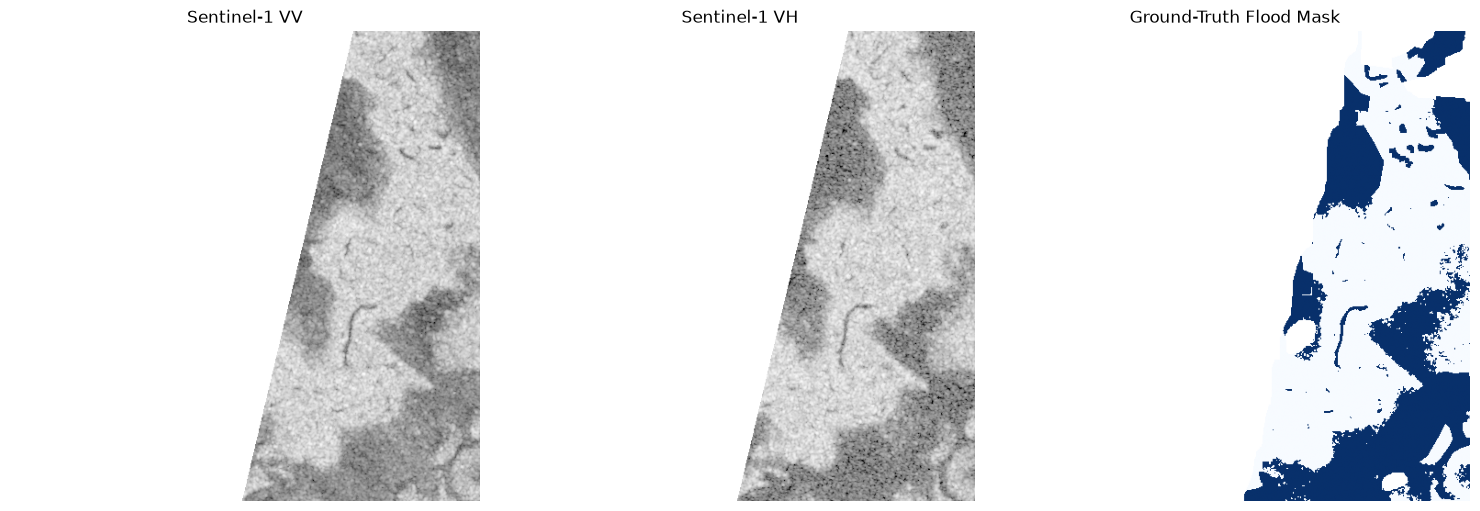

In [6]:
label_display = np.ma.masked_where(label == -1, label)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image[0], cmap="gray")
axes[0].set_title("Sentinel-1 VV")
axes[0].axis("off")

axes[1].imshow(image[1], cmap="gray")
axes[1].set_title("Sentinel-1 VH")
axes[1].axis("off")

axes[2].imshow(label_display, cmap="Blues")
axes[2].set_title("Ground-Truth Flood Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 7. Calculate Flood Statistics

To calculate flood coverage, NoData pixels (`-1`) are excluded.

The remaining pixels are divided into:

- Water pixels (`1`)
- Non-water pixels (`0`)

In [7]:
valid_pixels = label != -1

water_pixels = np.sum(label == 1)
non_water_pixels = np.sum(label == 0)
total_valid_pixels = np.sum(valid_pixels)

water_percentage = (water_pixels / total_valid_pixels) * 100
non_water_percentage = (non_water_pixels / total_valid_pixels) * 100

print("Valid pixels:", total_valid_pixels)
print("Water pixels:", water_pixels)
print("Non-water pixels:", non_water_pixels)
print("Water percentage:", round(water_percentage, 2), "%")
print("Non-water percentage:", round(non_water_percentage, 2), "%")

Valid pixels: 88077
Water pixels: 35362
Non-water pixels: 52715
Water percentage: 40.15 %
Non-water percentage: 59.85 %


## 9. Selecting Additional Valid Samples

The initial sample `Bolivia_103757` was used to verify the dataset structure and understand the relationship between Sentinel-1 imagery and flood labels.

A single image is not sufficient for training a machine learning model. Therefore, the next step is to identify a small collection of valid hand-labeled samples.

For each candidate label, we will check whether it contains valid water or non-water pixels.

Only samples containing labels other than `-1` will be considered for the next stage.

In [8]:
import requests

bucket_url = "https://storage.googleapis.com/storage/v1/b/sen1floods11/o"

params = {
    "prefix": "v1.1/data/flood_events/HandLabeled/LabelHand/",
    "maxResults": 1000
}

response = requests.get(bucket_url, params=params)

print("Status:", response.status_code)

data = response.json()

label_files = [
    item["name"]
    for item in data.get("items", [])
    if item["name"].endswith("_LabelHand.tif")
]

print("Number of label files found:", len(label_files))
print("\nFirst 10 files:")

for file in label_files[:10]:
    print(file)

Status: 200
Number of label files found: 446

First 10 files:
v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_103757_LabelHand.tif
v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_129334_LabelHand.tif
v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_195474_LabelHand.tif
v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_23014_LabelHand.tif
v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_233925_LabelHand.tif
v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_242570_LabelHand.tif
v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_290290_LabelHand.tif
v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_294583_LabelHand.tif
v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_312675_LabelHand.tif
v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_314919_LabelHand.tif


## 10. Checking Label Validity

Some Sen1Floods11 label files may contain only NoData pixels (`-1`).

Therefore, each candidate label is inspected before it is used.

A valid sample should contain at least one labeled pixel with value `0` or `1`.

This prevents invalid or empty samples from entering the machine learning dataset.

In [9]:
test_file = label_files[0]

print("Testing:", test_file)

test_url = "https://storage.googleapis.com/sen1floods11/" + test_file

response = requests.get(test_url, timeout=30)

print("Status:", response.status_code)
print("Size:", len(response.content), "bytes")

Testing: v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_103757_LabelHand.tif
Status: 200
Size: 7609 bytes


In [10]:
valid_samples = []

for file in label_files[:30]:

    filename = file.split("/")[-1]
    url = "https://storage.googleapis.com/sen1floods11/" + file

    try:
        response = requests.get(url, timeout=30)

        if response.status_code != 200:
            continue

        with rasterio.MemoryFile(response.content) as memfile:
            with memfile.open() as src:
                label_data = src.read(1)

        unique_values = np.unique(label_data)

        # Keep samples containing actual labeled pixels
        if 0 in unique_values or 1 in unique_values:
            valid_samples.append({
                "filename": filename,
                "values": unique_values.tolist()
            })

        # Stop once we have 10 usable samples
        if len(valid_samples) >= 10:
            break

    except Exception as e:
        print("Error:", filename, "|", e)

print("Valid samples found:", len(valid_samples))

print("\nSelected samples:")
for sample in valid_samples:
    print(sample["filename"], "→", sample["values"])

Valid samples found: 10

Selected samples:
Bolivia_103757_LabelHand.tif → [-1, 0, 1]
Bolivia_129334_LabelHand.tif → [-1, 0, 1]
Bolivia_195474_LabelHand.tif → [-1, 0, 1]
Bolivia_23014_LabelHand.tif → [-1, 0, 1]
Bolivia_233925_LabelHand.tif → [-1, 0, 1]
Bolivia_242570_LabelHand.tif → [-1, 0, 1]
Bolivia_290290_LabelHand.tif → [-1, 0, 1]
Bolivia_294583_LabelHand.tif → [-1, 0, 1]
Bolivia_312675_LabelHand.tif → [-1, 0, 1]
Bolivia_314919_LabelHand.tif → [-1, 0, 1]


## 11. Creating the Initial Sample Set

The Sen1Floods11 dataset provides pixel-level flood annotations.

For the initial Explainable AI experiment, a smaller image-level classification dataset will be created from these annotations.

Each selected satellite image will be paired with its corresponding hand-labeled flood mask.

The flood mask will be used to calculate the proportion of water pixels in each image.

This allows us to understand the composition of the selected samples before defining image-level classification labels.

The initial dataset is intentionally small because the objective at this stage is to develop and test the complete research workflow:

Satellite Image
→ CNN
→ Flood Prediction
→ Grad-CAM
→ SHAP

## 12. Calculating Water Percentage for Selected Samples

For each selected sample, the ground-truth mask is examined.

Only valid pixels (`0` and `1`) are considered.

The percentage of water pixels is calculated as:

Water Percentage =
(Water Pixels / Total Valid Pixels) × 100

This statistic will help us understand how much flooded area is present in each image before creating image-level classification labels.

In [11]:
selected_sample_stats = []

for sample in valid_samples:

    filename = sample["filename"]

    label_url = (
        "https://storage.googleapis.com/sen1floods11/"
        "v1.1/data/flood_events/HandLabeled/LabelHand/"
        + filename
    )

    response = requests.get(label_url, timeout=30)

    with rasterio.MemoryFile(response.content) as memfile:
        with memfile.open() as src:
            label_data = src.read(1)

    valid_pixels = label_data != -1

    water_pixels = np.sum(label_data == 1)
    non_water_pixels = np.sum(label_data == 0)
    total_valid_pixels = np.sum(valid_pixels)

    water_percentage = (
        water_pixels / total_valid_pixels
    ) * 100

    selected_sample_stats.append({
        "filename": filename,
        "water_pixels": int(water_pixels),
        "non_water_pixels": int(non_water_pixels),
        "water_percentage": round(water_percentage, 2)
    })

for sample in selected_sample_stats:
    print(
        sample["filename"],
        "→ Water:",
        sample["water_percentage"],
        "%"
    )

Bolivia_103757_LabelHand.tif → Water: 40.15 %
Bolivia_129334_LabelHand.tif → Water: 65.87 %
Bolivia_195474_LabelHand.tif → Water: 0.59 %
Bolivia_23014_LabelHand.tif → Water: 3.71 %
Bolivia_233925_LabelHand.tif → Water: 0.0 %
Bolivia_242570_LabelHand.tif → Water: 15.58 %
Bolivia_290290_LabelHand.tif → Water: 9.63 %
Bolivia_294583_LabelHand.tif → Water: 11.5 %
Bolivia_312675_LabelHand.tif → Water: 6.06 %
Bolivia_314919_LabelHand.tif → Water: 44.31 %


## 13. Defining Image-Level Classification Labels

Sen1Floods11 provides pixel-level water annotations. For this initial XAI classification experiment, an image-level label is derived from the percentage of valid pixels classified as water.

For this exploratory experiment, the following rule is used:

- **Flood:** water coverage ≥ 5%
- **Non-flood:** water coverage < 5%

The 5% threshold is an experimental preprocessing rule for converting the original segmentation labels into image-level classes. It is not the original Sen1Floods11 annotation scheme.

This conversion is used only to create a simple classification task for testing the CNN, Grad-CAM, and SHAP pipeline.

In [12]:
for sample in selected_sample_stats:

    if sample["water_percentage"] >= 5:
        sample["class"] = "Flood"
        sample["class_id"] = 1
    else:
        sample["class"] = "Non-Flood"
        sample["class_id"] = 0

print("Image-level labels:\n")

for sample in selected_sample_stats:
    print(
        sample["filename"],
        "→",
        sample["water_percentage"],
        "% →",
        sample["class"]
    )

Image-level labels:

Bolivia_103757_LabelHand.tif → 40.15 % → Flood
Bolivia_129334_LabelHand.tif → 65.87 % → Flood
Bolivia_195474_LabelHand.tif → 0.59 % → Non-Flood
Bolivia_23014_LabelHand.tif → 3.71 % → Non-Flood
Bolivia_233925_LabelHand.tif → 0.0 % → Non-Flood
Bolivia_242570_LabelHand.tif → 15.58 % → Flood
Bolivia_290290_LabelHand.tif → 9.63 % → Flood
Bolivia_294583_LabelHand.tif → 11.5 % → Flood
Bolivia_312675_LabelHand.tif → 6.06 % → Flood
Bolivia_314919_LabelHand.tif → 44.31 % → Flood


## 14. Expanding the Sample Set

The first 10 valid samples produced an imbalanced class distribution.

To make the initial classification experiment more suitable for model development, additional samples will be selected.

The target for this exploratory experiment is approximately:

- 10 Flood samples
- 10 Non-Flood samples

The samples will be selected using the same 5% water-coverage threshold defined above.

In [13]:
additional_samples = []

for file in label_files[30:100]:

    filename = file.split("/")[-1]

    url = "https://storage.googleapis.com/sen1floods11/" + file

    try:
        response = requests.get(url, timeout=30)

        if response.status_code != 200:
            continue

        with rasterio.MemoryFile(response.content) as memfile:
            with memfile.open() as src:
                label_data = src.read(1)

        valid_pixels = label_data != -1
        total_valid_pixels = np.sum(valid_pixels)

        if total_valid_pixels == 0:
            continue

        water_pixels = np.sum(label_data == 1)

        water_percentage = (
            water_pixels / total_valid_pixels
        ) * 100

        if water_percentage >= 5:
            image_class = "Flood"
            class_id = 1
        else:
            image_class = "Non-Flood"
            class_id = 0

        additional_samples.append({
            "filename": filename,
            "water_percentage": round(water_percentage, 2),
            "class": image_class,
            "class_id": class_id
        })

        # Count total samples including our original 10
        all_samples = selected_sample_stats + additional_samples

        flood_count = sum(
            sample.get("class") == "Flood"
            for sample in all_samples
        )

        non_flood_count = sum(
            sample.get("class") == "Non-Flood"
            for sample in all_samples
        )

        if flood_count >= 10 and non_flood_count >= 10:
            break

    except Exception:
        continue

print("Additional samples found:", len(additional_samples))

print("\nAdditional samples:")
for sample in additional_samples:
    print(
        sample["filename"],
        "→",
        sample["water_percentage"],
        "%",
        "→",
        sample["class"]
    )

all_samples = selected_sample_stats + additional_samples

flood_count = sum(
    sample.get("class") == "Flood"
    for sample in all_samples
)

non_flood_count = sum(
    sample.get("class") == "Non-Flood"
    for sample in all_samples
)

print("\nCurrent class distribution:")
print("Flood:", flood_count)
print("Non-Flood:", non_flood_count)

Additional samples found: 14

Additional samples:
Ghana_147015_LabelHand.tif → 1.35 % → Non-Flood
Ghana_154838_LabelHand.tif → 0.0 % → Non-Flood
Ghana_156478_LabelHand.tif → 0.0 % → Non-Flood
Ghana_161233_LabelHand.tif → 0.0 % → Non-Flood
Ghana_167233_LabelHand.tif → 0.0 % → Non-Flood
Ghana_168875_LabelHand.tif → 0.0 % → Non-Flood
Ghana_187318_LabelHand.tif → 0.0 % → Non-Flood
Ghana_194723_LabelHand.tif → 0.0 % → Non-Flood
Ghana_247288_LabelHand.tif → 66.34 % → Flood
Ghana_24858_LabelHand.tif → 0.18 % → Non-Flood
Ghana_264787_LabelHand.tif → 0.0 % → Non-Flood
Ghana_308249_LabelHand.tif → 3.06 % → Non-Flood
Ghana_313799_LabelHand.tif → 6.11 % → Flood
Ghana_319168_LabelHand.tif → 23.03 % → Flood

Current class distribution:
Flood: 10
Non-Flood: 14


## 15. Final Exploratory Sample Distribution

The initial sample selection produced 24 usable samples:

- 10 Flood samples
- 14 Non-Flood samples

The classes are moderately imbalanced, but the dataset is sufficient for an initial proof-of-concept experiment.

Because this study focuses on developing an Explainable AI workflow rather than benchmarking model performance, the selected subset will be used to demonstrate the complete pipeline.

Class imbalance will be considered during model training rather than expanding the dataset unnecessarily.

In [14]:
all_samples = []

# Add the original 10 samples
for sample in selected_sample_stats:
    all_samples.append({
        "filename": sample["filename"],
        "water_percentage": sample["water_percentage"],
        "class": sample["class"],
        "class_id": sample["class_id"]
    })

# Add the additional samples
all_samples.extend(additional_samples)

print("Total samples:", len(all_samples))

print("\nClass distribution:")

flood_count = sum(
    sample["class_id"] == 1
    for sample in all_samples
)

non_flood_count = sum(
    sample["class_id"] == 0
    for sample in all_samples
)

print("Flood:", flood_count)
print("Non-Flood:", non_flood_count)

Total samples: 24

Class distribution:
Flood: 10
Non-Flood: 14


## 16. Inspecting the Final Sample List

Before downloading the corresponding Sentinel-1 images, the final sample list is inspected.

Each sample contains:

- Filename
- Water coverage percentage
- Image-level class
- Numeric class ID

The numeric class IDs will later be used by the PyTorch classification model:

- `0` = Non-Flood
- `1` = Flood

In [15]:
for i, sample in enumerate(all_samples, start=1):

    print(
        f"{i:02d}.",
        sample["filename"],
        "| Water:",
        sample["water_percentage"],
        "%",
        "| Class:",
        sample["class"],
        "| ID:",
        sample["class_id"]
    )

01. Bolivia_103757_LabelHand.tif | Water: 40.15 % | Class: Flood | ID: 1
02. Bolivia_129334_LabelHand.tif | Water: 65.87 % | Class: Flood | ID: 1
03. Bolivia_195474_LabelHand.tif | Water: 0.59 % | Class: Non-Flood | ID: 0
04. Bolivia_23014_LabelHand.tif | Water: 3.71 % | Class: Non-Flood | ID: 0
05. Bolivia_233925_LabelHand.tif | Water: 0.0 % | Class: Non-Flood | ID: 0
06. Bolivia_242570_LabelHand.tif | Water: 15.58 % | Class: Flood | ID: 1
07. Bolivia_290290_LabelHand.tif | Water: 9.63 % | Class: Flood | ID: 1
08. Bolivia_294583_LabelHand.tif | Water: 11.5 % | Class: Flood | ID: 1
09. Bolivia_312675_LabelHand.tif | Water: 6.06 % | Class: Flood | ID: 1
10. Bolivia_314919_LabelHand.tif | Water: 44.31 % | Class: Flood | ID: 1
11. Ghana_147015_LabelHand.tif | Water: 1.35 % | Class: Non-Flood | ID: 0
12. Ghana_154838_LabelHand.tif | Water: 0.0 % | Class: Non-Flood | ID: 0
13. Ghana_156478_LabelHand.tif | Water: 0.0 % | Class: Non-Flood | ID: 0
14. Ghana_161233_LabelHand.tif | Water: 0.0 % 

## 17. Matching Sentinel-1 Images with Ground-Truth Labels

Each hand-labeled flood mask has a corresponding Sentinel-1 satellite image.

The naming convention is:

`EVENT_CHIPID_LabelHand.tif`
→
`EVENT_CHIPID_S1Hand.tif`

For example:

`Bolivia_103757_LabelHand.tif`
→
`Bolivia_103757_S1Hand.tif`

The Sentinel-1 images contain two SAR bands:

- VV
- VH

These two bands will be used as the input features for the deep learning model.

In [16]:
import requests

s1_dir = Path("../data/sen1floods11/S1Hand")
s1_dir.mkdir(parents=True, exist_ok=True)

downloaded_images = []

base_s1_url = (
    "https://storage.googleapis.com/sen1floods11/"
    "v1.1/data/flood_events/HandLabeled/S1Hand/"
)

for sample in all_samples:

    label_filename = sample["filename"]

    # Convert LabelHand filename to matching S1Hand filename
    s1_filename = label_filename.replace(
        "_LabelHand.tif",
        "_S1Hand.tif"
    )

    output_path = s1_dir / s1_filename

    # Skip files that are already downloaded
    if output_path.exists():
        downloaded_images.append(s1_filename)
        print("Already exists:", s1_filename)
        continue

    url = base_s1_url + s1_filename

    try:
        response = requests.get(url, timeout=60)

        if response.status_code == 200:
            output_path.write_bytes(response.content)
            downloaded_images.append(s1_filename)

            print(
                "Downloaded:",
                s1_filename,
                "|",
                round(len(response.content) / 1024, 2),
                "KB"
            )
        else:
            print(
                "Failed:",
                s1_filename,
                "| Status:",
                response.status_code
            )

    except Exception as e:
        print("Error:", s1_filename, "|", e)

print("\nTotal Sentinel-1 images available:", len(downloaded_images))

Already exists: Bolivia_103757_S1Hand.tif
Already exists: Bolivia_129334_S1Hand.tif
Already exists: Bolivia_195474_S1Hand.tif
Already exists: Bolivia_23014_S1Hand.tif
Already exists: Bolivia_233925_S1Hand.tif
Already exists: Bolivia_242570_S1Hand.tif
Already exists: Bolivia_290290_S1Hand.tif
Already exists: Bolivia_294583_S1Hand.tif
Already exists: Bolivia_312675_S1Hand.tif
Already exists: Bolivia_314919_S1Hand.tif
Already exists: Ghana_147015_S1Hand.tif
Already exists: Ghana_154838_S1Hand.tif
Already exists: Ghana_156478_S1Hand.tif
Already exists: Ghana_161233_S1Hand.tif
Already exists: Ghana_167233_S1Hand.tif
Already exists: Ghana_168875_S1Hand.tif
Already exists: Ghana_187318_S1Hand.tif
Already exists: Ghana_194723_S1Hand.tif
Already exists: Ghana_247288_S1Hand.tif
Already exists: Ghana_24858_S1Hand.tif
Already exists: Ghana_264787_S1Hand.tif
Already exists: Ghana_308249_S1Hand.tif
Already exists: Ghana_313799_S1Hand.tif
Already exists: Ghana_319168_S1Hand.tif

Total Sentinel-1 imag

## 18. Verifying Sentinel-1 Image Structure

Before model training, the downloaded Sentinel-1 images are checked for consistency.

Each image should contain:

- Two SAR bands: VV and VH
- A consistent spatial size
- Valid numerical values
- The expected coordinate reference system

This verification step helps detect corrupted or incompatible files before they are passed to the deep learning pipeline.

In [17]:
image_info = []

for sample in all_samples:

    s1_filename = sample["filename"].replace(
        "_LabelHand.tif",
        "_S1Hand.tif"
    )

    image_path = s1_dir / s1_filename

    with rasterio.open(image_path) as src:

        image_info.append({
            "filename": s1_filename,
            "shape": (src.count, src.height, src.width),
            "dtype": str(src.dtypes[0]),
            "crs": str(src.crs)
        })

for info in image_info:
    print(
        info["filename"],
        "| Shape:", info["shape"],
        "| Dtype:", info["dtype"],
        "| CRS:", info["crs"]
    )

Bolivia_103757_S1Hand.tif | Shape: (2, 512, 512) | Dtype: float32 | CRS: EPSG:4326
Bolivia_129334_S1Hand.tif | Shape: (2, 512, 512) | Dtype: float32 | CRS: EPSG:4326
Bolivia_195474_S1Hand.tif | Shape: (2, 512, 512) | Dtype: float32 | CRS: EPSG:4326
Bolivia_23014_S1Hand.tif | Shape: (2, 512, 512) | Dtype: float32 | CRS: EPSG:4326
Bolivia_233925_S1Hand.tif | Shape: (2, 512, 512) | Dtype: float32 | CRS: EPSG:4326
Bolivia_242570_S1Hand.tif | Shape: (2, 512, 512) | Dtype: float32 | CRS: EPSG:4326
Bolivia_290290_S1Hand.tif | Shape: (2, 512, 512) | Dtype: float32 | CRS: EPSG:4326
Bolivia_294583_S1Hand.tif | Shape: (2, 512, 512) | Dtype: float32 | CRS: EPSG:4326
Bolivia_312675_S1Hand.tif | Shape: (2, 512, 512) | Dtype: float32 | CRS: EPSG:4326
Bolivia_314919_S1Hand.tif | Shape: (2, 512, 512) | Dtype: float32 | CRS: EPSG:4326
Ghana_147015_S1Hand.tif | Shape: (2, 512, 512) | Dtype: float32 | CRS: EPSG:4326
Ghana_154838_S1Hand.tif | Shape: (2, 512, 512) | Dtype: float32 | CRS: EPSG:4326
Ghana_156

## 19. Sentinel-1 Preprocessing

The Sentinel-1 images contain two SAR channels:

- VV
- VH

For the initial CNN experiment, each image will be:

1. Loaded as a two-channel array.
2. Converted to `float32`.
3. Standardized independently for each channel.
4. Resized from `512 × 512` to `128 × 128`.

Standardization is performed using:

X_normalized = (X - mean) / standard deviation

Per-channel normalization helps place the VV and VH values on comparable numerical scales.

The resulting input shape for the CNN will be:

`(2, 128, 128)`

where:

- `2` = VV and VH channels
- `128 × 128` = resized spatial dimensions

In [18]:
from rasterio.enums import Resampling

sample_image_path = s1_dir / "Bolivia_103757_S1Hand.tif"

with rasterio.open(sample_image_path) as src:
    sample_image = src.read(
        out_shape=(2, 128, 128),
        resampling=Resampling.bilinear
    ).astype(np.float32)

print("Original expected shape: (2, 512, 512)")
print("Preprocessed shape:", sample_image.shape)

for i, band in enumerate(sample_image, start=1):

    valid_values = band[np.isfinite(band)]

    mean = np.mean(valid_values)
    std = np.std(valid_values)

    print(
        f"Band {i}:",
        "mean =", round(float(mean), 4),
        "| std =", round(float(std), 4)
    )

Original expected shape: (2, 512, 512)
Preprocessed shape: (2, 128, 128)
Band 1: mean = -13.079 | std = 5.1714
Band 2: mean = -19.3571 | std = 5.7805


## 20. Normalizing Sentinel-1 Channels

The resized Sentinel-1 image contains two channels:

- VV
- VH

Each channel is standardized independently using its mean and standard deviation:

X_normalized = (X - mean) / standard deviation

Only finite pixel values are used when calculating the statistics.

This transforms the input values into a more suitable numerical range for CNN training while preserving the relative information in the SAR channels.

After normalization, the two channels will be used as the input to the classification model.

In [19]:
normalized_image = np.zeros_like(sample_image, dtype=np.float32)

for i, band in enumerate(sample_image):

    valid_mask = np.isfinite(band)

    valid_values = band[valid_mask]

    mean = np.mean(valid_values)
    std = np.std(valid_values)

    normalized_band = np.zeros_like(band, dtype=np.float32)

    normalized_band[valid_mask] = (
        (band[valid_mask] - mean) / std
    )

    normalized_image[i] = normalized_band

print("Normalized image shape:", normalized_image.shape)

for i, band in enumerate(normalized_image, start=1):

    valid_values = band[np.isfinite(band)]

    print(
        f"Band {i}:",
        "mean =", round(float(np.mean(valid_values)), 4),
        "| std =", round(float(np.std(valid_values)), 4),
        "| min =", round(float(np.min(valid_values)), 4),
        "| max =", round(float(np.max(valid_values)), 4)
    )

Normalized image shape: (2, 128, 128)
Band 1: mean = -0.0 | std = 0.6295 | min = -3.186 | max = 1.6321
Band 2: mean = -0.0 | std = 0.6295 | min = -3.2415 | max = 1.5742


## 21. Handling NoData Values During Preprocessing

Satellite imagery may contain invalid or NoData pixels.

These pixels should not influence the normalization statistics because they do not represent meaningful satellite observations.

Therefore, the preprocessing pipeline will:

1. Read the Sentinel-1 VV and VH bands.
2. Resize the image to `128 × 128`.
3. Identify finite pixels.
4. Calculate the mean and standard deviation using only valid pixels.
5. Normalize the valid pixels.
6. Replace remaining invalid pixels with `0`.

The final CNN input will have the shape:

`(2, 128, 128)`

with two normalized SAR channels:

- Channel 1 → VV
- Channel 2 → VH

In [20]:
from rasterio.enums import Resampling

def preprocess_s1(image_path, target_size=(128, 128)):

    with rasterio.open(image_path) as src:

        image = src.read(
            out_shape=(src.count, target_size[0], target_size[1]),
            resampling=Resampling.bilinear
        ).astype(np.float32)

    normalized_image = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):

        band = image[i]

        valid_mask = np.isfinite(band)

        valid_values = band[valid_mask]

        mean = np.mean(valid_values)
        std = np.std(valid_values)

        if std == 0:
            std = 1.0

        normalized_band = np.zeros_like(band, dtype=np.float32)

        normalized_band[valid_mask] = (
            (band[valid_mask] - mean) / std
        )

        normalized_image[i] = normalized_band

    return normalized_image

In [21]:
processed_sample = preprocess_s1(
    s1_dir / "Bolivia_103757_S1Hand.tif"
)

print("Processed shape:", processed_sample.shape)

for i, band in enumerate(processed_sample, start=1):

    valid_values = band[np.isfinite(band)]

    print(
        f"Band {i}:",
        "mean =", round(float(np.mean(valid_values)), 4),
        "| std =", round(float(np.std(valid_values)), 4),
        "| min =", round(float(np.min(valid_values)), 4),
        "| max =", round(float(np.max(valid_values)), 4)
    )

Processed shape: (2, 128, 128)
Band 1: mean = -0.0 | std = 0.6295 | min = -3.186 | max = 1.6321
Band 2: mean = -0.0 | std = 0.6295 | min = -3.2415 | max = 1.5742


In [22]:
for i, band in enumerate(sample_image, start=1):

    valid_mask = np.isfinite(band)
    valid_values = band[valid_mask]

    mean = np.mean(valid_values)
    std = np.std(valid_values)

    normalized_values = (
        (valid_values - mean) / std
    )

    print(f"Band {i}")
    print("Original mean:", round(float(mean), 4))
    print("Original std:", round(float(std), 4))
    print(
        "Normalized mean:",
        round(float(np.mean(normalized_values)), 4)
    )
    print(
        "Normalized std:",
        round(float(np.std(normalized_values)), 4)
    )
    print()

Band 1
Original mean: -13.079
Original std: 5.1714
Normalized mean: -0.0
Normalized std: 1.0

Band 2
Original mean: -19.3571
Original std: 5.7805
Normalized mean: -0.0
Normalized std: 1.0



## 22. Building the Preprocessed Dataset

The preprocessing pipeline is now applied to all selected Sentinel-1 samples.

For every sample:

1. The corresponding Sentinel-1 image is loaded.
2. VV and VH channels are extracted.
3. The image is resized to `128 × 128`.
4. Each channel is standardized independently.
5. The processed image is stored in the dataset.
6. The corresponding image-level class is stored as the target label.

The resulting dataset will contain:

- `X` → Sentinel-1 image data
- `y` → image-level flood classification labels

Expected shapes:

`X → (24, 2, 128, 128)`

`y → (24,)`

where:

- `24` = number of selected samples
- `2` = VV and VH channels
- `128 × 128` = spatial dimensions
- `0` = Non-Flood
- `1` = Flood

This dataset is an exploratory classification subset derived from the original pixel-level Sen1Floods11 annotations.

In [23]:
X = []
y = []

for sample in all_samples:

    s1_filename = sample["filename"].replace(
        "_LabelHand.tif",
        "_S1Hand.tif"
    )

    image_path = s1_dir / s1_filename

    processed_image = preprocess_s1(image_path)

    X.append(processed_image)
    y.append(sample["class_id"])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print("Dataset created successfully.")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset created successfully.
X shape: (24, 2, 128, 128)
y shape: (24,)


## 23. Verifying Dataset Labels

The image-level labels were derived from the original Sen1Floods11 flood masks.

Before model training, the final dataset is checked to ensure that:

- The number of images matches the number of labels.
- Both classes are present.
- The class distribution is known.
- The input values contain no unexpected infinite values.

Class IDs:

- `0` = Non-Flood
- `1` = Flood

In [24]:
print("Number of samples:", len(X))
print("Number of labels:", len(y))

print("\nClass distribution:")

unique_classes, class_counts = np.unique(y, return_counts=True)

for class_id, count in zip(unique_classes, class_counts):

    class_name = "Flood" if class_id == 1 else "Non-Flood"

    print(
        f"Class {class_id} ({class_name}):",
        count
    )

print("\nInput validation:")

print("Contains NaN:", np.isnan(X).any())
print("Contains infinite values:", np.isinf(X).any())

print("\nValue range:")
print("Minimum:", float(X.min()))
print("Maximum:", float(X.max()))

Number of samples: 24
Number of labels: 24

Class distribution:
Class 0 (Non-Flood): 14
Class 1 (Flood): 10

Input validation:
Contains NaN: False
Contains infinite values: False

Value range:
Minimum: -16.9110107421875
Maximum: 6.870702743530273


## 24. Preparing the Dataset for Deep Learning

The preprocessed Sentinel-1 dataset is currently stored as NumPy arrays.

Before training a CNN, the data will be converted into PyTorch tensors.

PyTorch will be used to:

- Build the flood classification model.
- Train the model on Sentinel-1 VV and VH imagery.
- Generate flood predictions.
- Later apply Grad-CAM and SHAP for Explainable AI analysis.

The current input format is:

`X → (24, 2, 128, 128)`

`y → (24,)`

In [25]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.14.0+cpu
CUDA available: False


## 25. Converting the Dataset to PyTorch Tensors

The preprocessed NumPy arrays will now be converted into PyTorch tensors.

PyTorch models expect image data in the format:

`(batch_size, channels, height, width)`

Our dataset already follows this structure:

`X → (24, 2, 128, 128)`

The target labels are stored as:

`y → (24,)`

where:

- `0` = Non-Flood
- `1` = Flood

In [26]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

print("X tensor shape:", X_tensor.shape)
print("X tensor dtype:", X_tensor.dtype)

print("y tensor shape:", y_tensor.shape)
print("y tensor dtype:", y_tensor.dtype)

X tensor shape: torch.Size([24, 2, 128, 128])
X tensor dtype: torch.float32
y tensor shape: torch.Size([24])
y tensor dtype: torch.int64


## 26. Creating Training and Testing Sets

The dataset will be divided into:

- **80% training data**
- **20% testing data**

Because the dataset is small and contains two classes, a stratified split is used.

Stratification ensures that both the Flood and Non-Flood classes are represented in the training and testing sets.

A fixed random state is used so that the experiment is reproducible.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tensor,
    y_tensor,
    test_size=0.2,
    random_state=42,
    stratify=y_tensor
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print("Non-Flood:", int((y_train == 0).sum()))
print("Flood:", int((y_train == 1).sum()))

print("\nTesting class distribution:")
print("Non-Flood:", int((y_test == 0).sum()))
print("Flood:", int((y_test == 1).sum()))

Training samples: 19
Testing samples: 5

Training class distribution:
Non-Flood: 11
Flood: 8

Testing class distribution:
Non-Flood: 3
Flood: 2


## 27. Building a CNN for Flood Classification

A Convolutional Neural Network (CNN) will be used to classify each Sentinel-1 image as either Flood or Non-Flood.

The model receives two input channels:

- Channel 1 → VV
- Channel 2 → VH

The CNN learns spatial patterns from these two SAR channels.

### Model Structure

Input `(2, 128, 128)`
→ Convolution
→ ReLU
→ Max Pooling
→ Convolution
→ ReLU
→ Max Pooling
→ Convolution
→ ReLU
→ Global Average Pooling
→ Fully Connected Layer
→ Flood / Non-Flood prediction

The model is intentionally kept small because this is an exploratory proof-of-concept using only 24 samples.

In [28]:
import torch.nn as nn

class FloodCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=2,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Linear(64, 2)

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

In [29]:
model = FloodCNN()

print(model)

FloodCNN(
  (features): Sequential(
    (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)


## 28. Configuring the Training Process

The CNN will be trained using:

- **Loss function:** Cross-Entropy Loss
- **Optimizer:** Adam
- **Learning rate:** `0.001`
- **Epochs:** `30`

Class weights are used because the training set contains:

- 11 Non-Flood samples
- 8 Flood samples

The model will learn to output two classes:

- `0` → Non-Flood
- `1` → Flood

In [30]:
# Calculate class weights

class_counts = torch.bincount(y_train)

class_weights = len(y_train) / (
    len(class_counts) * class_counts.float()
)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: tensor([11,  8])
Class weights: tensor([0.8636, 1.1875])


## 29. Defining the Loss Function and Optimizer

Cross-Entropy Loss is used because this is a two-class classification problem.

Class weights are supplied to the loss function so that the smaller Flood class receives slightly greater importance during training.

The Adam optimizer is used to update the CNN parameters based on the calculated gradients.

In [31]:
device = torch.device("cpu")

model = FloodCNN().to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Device:", device)
print("Loss function:", criterion)
print("Optimizer:", optimizer)

Device: cpu
Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 30. Training the CNN

The CNN will now be trained using the 19 training samples.

During each epoch:

1. The model receives the Sentinel-1 VV and VH images.
2. The model produces predictions for the two classes.
3. Cross-Entropy Loss measures the prediction error.
4. Backpropagation calculates the gradients.
5. Adam updates the model parameters.

The training loss will be recorded for every epoch so that the learning process can be examined afterwards.

In [32]:
num_epochs = 30

train_losses = []

X_train = X_train.to(device)
y_train = y_train.to(device)

model.train()

for epoch in range(num_epochs):

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    print(
        f"Epoch [{epoch + 1:02d}/{num_epochs}] "
        f"Loss: {loss.item():.4f}"
    )

Epoch [01/30] Loss: 0.6903
Epoch [02/30] Loss: 0.6786
Epoch [03/30] Loss: 0.6681
Epoch [04/30] Loss: 0.6578
Epoch [05/30] Loss: 0.6466
Epoch [06/30] Loss: 0.6331
Epoch [07/30] Loss: 0.6171
Epoch [08/30] Loss: 0.5987
Epoch [09/30] Loss: 0.5775
Epoch [10/30] Loss: 0.5532
Epoch [11/30] Loss: 0.5259
Epoch [12/30] Loss: 0.4960
Epoch [13/30] Loss: 0.4643
Epoch [14/30] Loss: 0.4318
Epoch [15/30] Loss: 0.3999
Epoch [16/30] Loss: 0.3700
Epoch [17/30] Loss: 0.3436
Epoch [18/30] Loss: 0.3215
Epoch [19/30] Loss: 0.3040
Epoch [20/30] Loss: 0.2910
Epoch [21/30] Loss: 0.2818
Epoch [22/30] Loss: 0.2755
Epoch [23/30] Loss: 0.2710
Epoch [24/30] Loss: 0.2673
Epoch [25/30] Loss: 0.2637
Epoch [26/30] Loss: 0.2595
Epoch [27/30] Loss: 0.2544
Epoch [28/30] Loss: 0.2484
Epoch [29/30] Loss: 0.2416
Epoch [30/30] Loss: 0.2342


## 31. Evaluating the CNN on Unseen Data

The trained CNN will now be evaluated using the five testing samples that were not used during training.

The model will generate a prediction for each test image.

The predicted class will be compared with the ground-truth class:

- `0` → Non-Flood
- `1` → Flood

This provides an initial indication of how the model performs on unseen satellite imagery.

In [33]:
model.eval()

with torch.no_grad():

    test_outputs = model(X_test)

    test_predictions = torch.argmax(
        test_outputs,
        dim=1
    )

print("Predictions:", test_predictions.cpu().numpy())
print("Actual labels:", y_test.cpu().numpy())

Predictions: [1 0 0 0 1]
Actual labels: [1 0 0 0 1]


## 32. Evaluating Classification Performance

The predictions are compared with the ground-truth labels using standard classification metrics.

The evaluation will include:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

Because the test set contains only five samples, these metrics should be interpreted as preliminary results from a small proof-of-concept experiment rather than as a benchmark of general flood-detection performance.

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_true = y_test.cpu().numpy()
y_pred = test_predictions.cpu().numpy()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

cm = confusion_matrix(y_true, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

print("\nConfusion Matrix:")
print(cm)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Confusion Matrix:
[[3 0]
 [0 2]]


## 33. Understanding Grad-CAM

Grad-CAM (Gradient-weighted Class Activation Mapping) is an Explainable AI technique used to visualize which regions of an image contributed most to a model's prediction.

For this flood-classification model, Grad-CAM helps answer:

> "Where was the CNN looking when it predicted Flood or Non-Flood?"

Grad-CAM uses the gradients flowing through a selected convolutional layer to create a spatial importance map.

The resulting heatmap can be overlaid on the original Sentinel-1 image.

### Research Objective

The purpose of Grad-CAM in this study is to examine whether the CNN focuses on spatial regions that are visually or structurally associated with the flood prediction.

Grad-CAM explains **where** the model is focusing, rather than directly explaining the numerical contribution of every input feature.

## 34. Selecting the Grad-CAM Target Layer

The final convolutional layer of the CNN contains spatial feature maps that represent higher-level patterns learned by the model.

This layer is selected as the initial Grad-CAM target layer:

`model.features[6]`

It corresponds to:

`Conv2d(32, 64, kernel_size=3, padding=1)`

The Grad-CAM procedure will use:

1. Activations from this convolutional layer.
2. Gradients of the predicted class with respect to those activations.
3. A weighted combination of the feature maps.
4. ReLU to retain positive contributions.
5. Upsampling to the original `128 × 128` image size.

The resulting map will show the spatial regions that contributed most strongly to the selected prediction.

In [35]:
target_layer = model.features[6]

print("Grad-CAM target layer:")
print(target_layer)

Grad-CAM target layer:
Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


## 35. Implementing Grad-CAM

Grad-CAM explains a model prediction using the activations and gradients from a convolutional layer.

The process is:

1. Pass an image through the CNN.
2. Obtain the model's prediction.
3. Select the predicted class.
4. Calculate gradients of that class score with respect to the target convolutional layer.
5. Average the gradients to obtain importance weights.
6. Weight the feature maps using these importance weights.
7. Apply ReLU to retain positive contributions.
8. Normalize the resulting heatmap.
9. Resize the heatmap to `128 × 128`.

The final heatmap represents the spatial regions that contributed most strongly to the model's prediction.

In [36]:
def generate_gradcam(model, image_tensor, target_layer):

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    forward_handle = target_layer.register_forward_hook(
        forward_hook
    )

    backward_handle = target_layer.register_full_backward_hook(
        backward_hook
    )

    model.zero_grad()

    output = model(image_tensor)

    predicted_class = torch.argmax(output, dim=1).item()

    class_score = output[0, predicted_class]

    class_score.backward()

    activation = activations[0]
    gradient = gradients[0]

    weights = gradient.mean(
        dim=(2, 3),
        keepdim=True
    )

    cam = (weights * activation).sum(dim=1)

    cam = torch.relu(cam)

    cam = cam.squeeze(0).detach().cpu().numpy()

    cam_min = cam.min()
    cam_max = cam.max()

    if cam_max - cam_min > 0:
        cam = (
            (cam - cam_min)
            / (cam_max - cam_min)
        )
    else:
        cam = np.zeros_like(cam)

    forward_handle.remove()
    backward_handle.remove()

    return cam, predicted_class, output

In [37]:
test_index = 0

test_image = X_test[test_index].unsqueeze(0)

model.eval()

cam, predicted_class, output = generate_gradcam(
    model,
    test_image,
    target_layer
)

actual_class = y_test[test_index].item()

print("Actual class:", actual_class)
print("Predicted class:", predicted_class)
print("Model output:", output.detach().numpy())
print("Grad-CAM shape:", cam.shape)
print("Grad-CAM range:", cam.min(), "to", cam.max())

Actual class: 1
Predicted class: 1
Model output: [[-2.4365644  2.204024 ]]
Grad-CAM shape: (32, 32)
Grad-CAM range: 0.0 to 1.0


## 36. Visualizing the Grad-CAM Explanation

The Grad-CAM heatmap is currently `32 × 32`.

It will be resized to `128 × 128` so that it can be overlaid on the Sentinel-1 image.

The visualization will contain:

1. The Sentinel-1 VV channel.
2. The Grad-CAM heatmap.
3. The VV image with the Grad-CAM heatmap overlaid.

Regions with stronger Grad-CAM activation indicate areas that contributed more strongly to the selected model prediction.

For this example, the selected prediction is:

`Flood`

In [38]:
import torch.nn.functional as F

cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0)

cam_resized = F.interpolate(
    cam_tensor,
    size=(128, 128),
    mode="bilinear",
    align_corners=False
)

cam_resized = cam_resized.squeeze().numpy()

print("Original Grad-CAM shape:", cam.shape)
print("Resized Grad-CAM shape:", cam_resized.shape)

Original Grad-CAM shape: (32, 32)
Resized Grad-CAM shape: (128, 128)


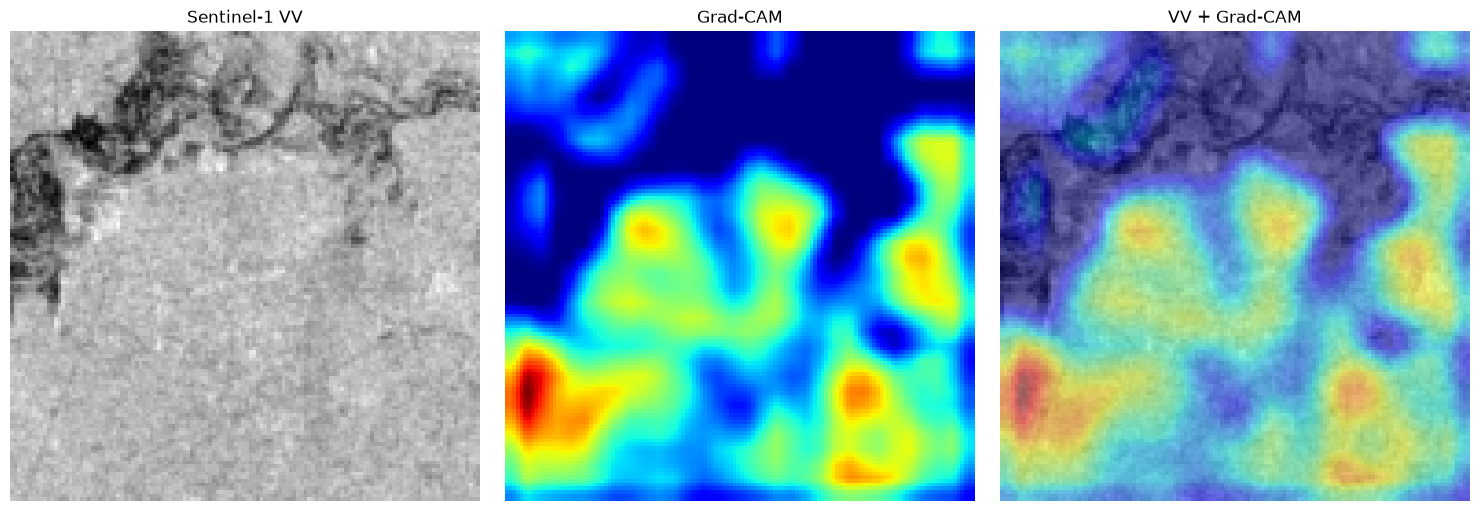

In [39]:
test_image_np = test_image.squeeze(0).cpu().numpy()

vv_image = test_image_np[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(vv_image, cmap="gray")
axes[0].set_title("Sentinel-1 VV")
axes[0].axis("off")

axes[1].imshow(cam_resized, cmap="jet")
axes[1].set_title("Grad-CAM")
axes[1].axis("off")

axes[2].imshow(vv_image, cmap="gray")
axes[2].imshow(
    cam_resized,
    cmap="jet",
    alpha=0.5
)
axes[2].set_title("VV + Grad-CAM")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 37. Comparing Grad-CAM with the Ground-Truth Flood Mask

Grad-CAM identifies regions that contributed to the CNN's prediction.

The Sen1Floods11 ground-truth mask identifies pixels annotated as:

- `1` → Water
- `0` → Not Water
- `-1` → NoData

The Grad-CAM explanation will be compared with the ground-truth mask to examine whether regions receiving high model attention overlap with annotated water regions.

This comparison does not prove that the model has learned the correct physical features. It provides an initial quantitative measure of the relationship between model attention and the available flood annotations.

In [40]:
# Identify the filename corresponding to the selected test image

test_image_tensor = X_test[test_index]

# Find the matching sample using the label value and image data
test_label = y_test[test_index].item()

print("Test image index:", test_index)
print("Actual class:", test_label)

Test image index: 0
Actual class: 1


## 38. Tracking Test Sample Metadata

For Explainable AI analysis, it is important to retain the identity of each satellite image.

The original dataset contains metadata such as:

- Event/chip filename
- Water coverage percentage
- Image-level class

The test split was created from the ordered `all_samples` list, so the corresponding sample indices will now be tracked.

In [41]:
sample_indices = np.arange(len(all_samples))

train_indices, test_indices = train_test_split(
    sample_indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Test sample indices:", test_indices)

print("\nTest samples:")

for index in test_indices:

    sample = all_samples[index]

    print(
        sample["filename"],
        "| Water:",
        sample["water_percentage"],
        "%",
        "| Class:",
        sample["class"]
    )

Test sample indices: [23 10 13 17 18]

Test samples:
Ghana_319168_LabelHand.tif | Water: 23.03 % | Class: Flood
Ghana_147015_LabelHand.tif | Water: 1.35 % | Class: Non-Flood
Ghana_161233_LabelHand.tif | Water: 0.0 % | Class: Non-Flood
Ghana_194723_LabelHand.tif | Water: 0.0 % | Class: Non-Flood
Ghana_247288_LabelHand.tif | Water: 66.34 % | Class: Flood


## 39. Loading the Ground-Truth Mask for the Grad-CAM Sample

The first test sample used for Grad-CAM will be matched with its original Sen1Floods11 ground-truth mask.

The ground-truth mask contains:

- `1` → Water
- `0` → Not Water
- `-1` → NoData

The mask will be resized to `128 × 128` so that it can be compared with the Grad-CAM heatmap.

The comparison will allow us to visually inspect whether areas emphasized by the CNN correspond to annotated water regions.

In [42]:
# Get the original dataset index of the first test image

original_index = test_indices[test_index]

sample = all_samples[original_index]

label_filename = sample["filename"]

label_path = Path(
    "../data/sen1floods11/LabelHand"
) / label_filename

print("Selected sample:", label_filename)
print("Class:", sample["class"])
print("Water coverage:", sample["water_percentage"], "%")

Selected sample: Ghana_319168_LabelHand.tif
Class: Flood
Water coverage: 23.03 %


In [43]:
## Download the ground-truth label for the selected Grad-CAM sample

original_index = test_indices[test_index]

sample = all_samples[original_index]

label_filename = sample["filename"]

label_dir = Path("../data/sen1floods11/LabelHand")
label_dir.mkdir(parents=True, exist_ok=True)

label_path = label_dir / label_filename

print("Selected sample:", label_filename)
print("Class:", sample["class"])
print("Water coverage:", sample["water_percentage"], "%")

if not label_path.exists():

    label_url = (
        "https://storage.googleapis.com/sen1floods11/"
        "v1.1/data/flood_events/HandLabeled/LabelHand/"
        + label_filename
    )

    response = requests.get(label_url, timeout=60)

    print("Download status:", response.status_code)

    if response.status_code == 200:
        label_path.write_bytes(response.content)
        print("Label downloaded successfully.")
    else:
        print("Failed to download label.")

else:
    print("Label already exists.")

print("Label exists:", label_path.exists())

Selected sample: Ghana_319168_LabelHand.tif
Class: Flood
Water coverage: 23.03 %
Label already exists.
Label exists: True


In [44]:
with rasterio.open(label_path) as src:

    ground_truth = src.read(
        1,
        out_shape=(128, 128),
        resampling=Resampling.nearest
    )

print("Ground-truth shape:", ground_truth.shape)
print("Ground-truth values:", np.unique(ground_truth))

Ground-truth shape: (128, 128)
Ground-truth values: [-1  0  1]


## 40. Comparing Grad-CAM with the Ground-Truth Flood Mask

The Grad-CAM heatmap shows the regions that contributed most strongly to the CNN's prediction.

The ground-truth mask shows the actual water regions annotated in Sen1Floods11.

This visualization compares both explanations side by side:

- **Sentinel-1 VV** → original model input channel
- **Ground Truth** → annotated water regions
- **Grad-CAM** → regions emphasized by the CNN
- **Grad-CAM + Ground Truth** → visual comparison between model attention and annotated water

The purpose is to examine whether the model's important regions spatially correspond to the annotated flood regions.

This is an exploratory XAI analysis and does not establish that Grad-CAM provides a complete or causal explanation of the model.

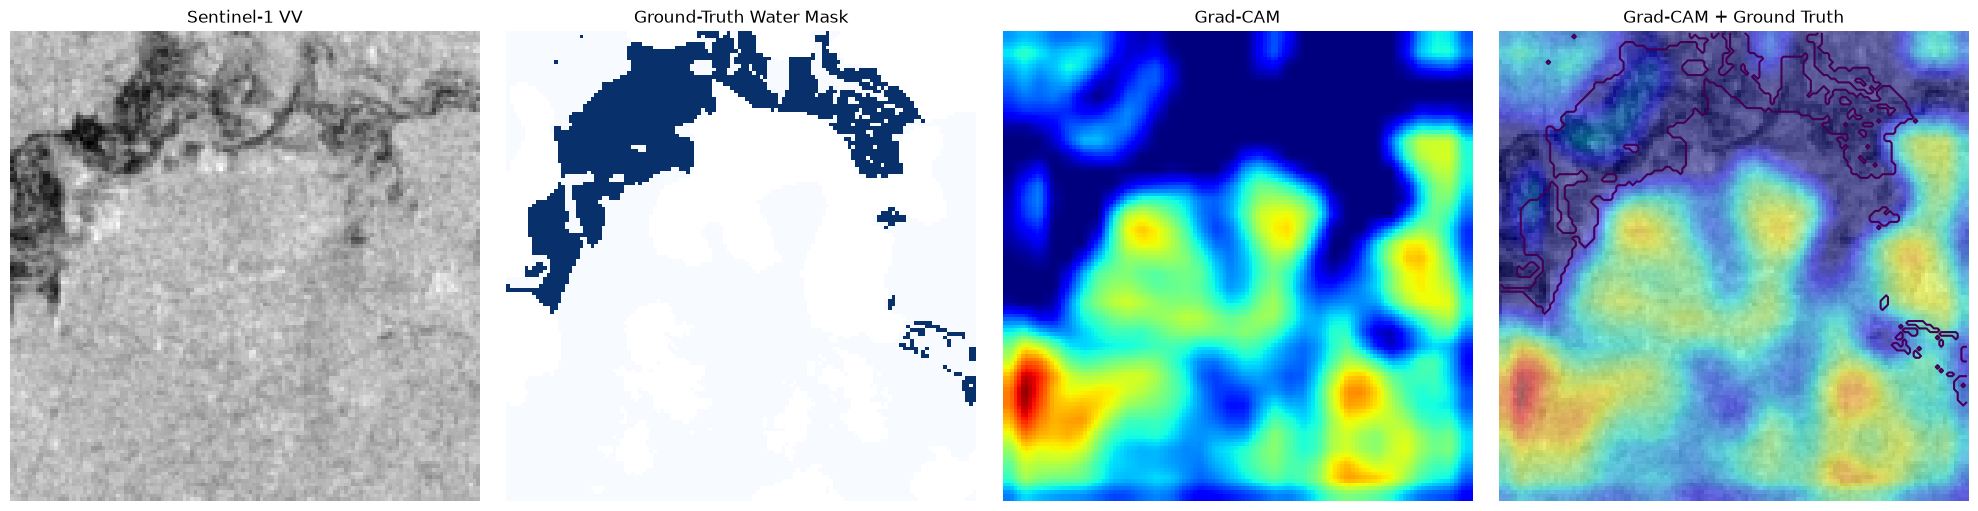

In [45]:
# Prepare the ground-truth mask for visualization

ground_truth_display = np.ma.masked_where(
    ground_truth == -1,
    ground_truth
)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 1. Sentinel-1 VV
axes[0].imshow(vv_image, cmap="gray")
axes[0].set_title("Sentinel-1 VV")
axes[0].axis("off")

# 2. Ground Truth
axes[1].imshow(
    ground_truth_display,
    cmap="Blues",
    vmin=0,
    vmax=1
)
axes[1].set_title("Ground-Truth Water Mask")
axes[1].axis("off")

# 3. Grad-CAM
axes[2].imshow(
    cam_resized,
    cmap="jet",
    vmin=0,
    vmax=1
)
axes[2].set_title("Grad-CAM")
axes[2].axis("off")

# 4. Grad-CAM + Ground Truth
axes[3].imshow(vv_image, cmap="gray")

axes[3].imshow(
    cam_resized,
    cmap="jet",
    alpha=0.5,
    vmin=0,
    vmax=1
)

axes[3].contour(
    ground_truth == 1,
    levels=[0.5],
    linewidths=1.5
)

axes[3].set_title("Grad-CAM + Ground Truth")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## 41. Quantitative Grad-CAM and Flood-Mask Overlap

Visual inspection provides a qualitative comparison between Grad-CAM and the ground-truth flood mask.

To obtain a simple quantitative measure, the Grad-CAM heatmap is converted into a binary importance mask.

For this exploratory analysis, pixels in the top 20% of Grad-CAM activation values are considered highly important.

This high-activation region is then compared with the annotated water pixels in the ground-truth mask.

The overlap is calculated as:

Overlap =
(Highly Important Pixels ∩ Water Pixels)
/
Highly Important Pixels

A higher value indicates that a larger proportion of the model's highly activated regions coincide with annotated water regions.

This metric is used only as an exploratory XAI measure. It should not be interpreted as a standard Grad-CAM evaluation metric or as proof that the model has learned physically meaningful flood features.

In [46]:
# Create masks for valid ground-truth pixels and water pixels

valid_mask = ground_truth != -1
water_mask = ground_truth == 1

# Select the top 20% Grad-CAM activation pixels
threshold = np.percentile(
    cam_resized[valid_mask],
    80
)

gradcam_high = (
    cam_resized >= threshold
) & valid_mask

# Calculate overlap
high_activation_pixels = np.sum(gradcam_high)

overlapping_water_pixels = np.sum(
    gradcam_high & water_mask
)

if high_activation_pixels > 0:

    overlap_percentage = (
        overlapping_water_pixels /
        high_activation_pixels
    ) * 100

else:

    overlap_percentage = 0


print("Grad-CAM threshold:", round(float(threshold), 4))
print(
    "Highly activated pixels:",
    int(high_activation_pixels)
)
print(
    "Highly activated pixels overlapping water:",
    int(overlapping_water_pixels)
)
print(
    "Water overlap:",
    round(float(overlap_percentage), 2),
    "%"
)

Grad-CAM threshold: 0.5188
Highly activated pixels: 2146
Highly activated pixels overlapping water: 0
Water overlap: 0.0 %


## 42. Understanding SHAP for Satellite Flood Classification

SHAP (SHapley Additive exPlanations) is an Explainable AI method used to estimate how different input features contribute to a model's prediction.

In this study, the CNN receives two Sentinel-1 SAR channels:

- VV
- VH

SHAP will be used to investigate which input regions and channels contribute toward the model's Flood or Non-Flood prediction.

### Grad-CAM vs SHAP

Grad-CAM answers:

> "Where is the CNN focusing?"

SHAP answers:

> "Which input features are contributing to the prediction, and in which direction?"

For the satellite imagery experiment, SHAP values can provide spatial attribution maps for the VV and VH channels.

This creates a complementary explanation:

Satellite Image
→ CNN Prediction
→ Grad-CAM: Spatial attention
→ SHAP: Feature contribution

The SHAP analysis will be performed on the same test sample used for the Grad-CAM experiment so that the two XAI methods can be compared.

## 43. Installing and Importing SHAP

The SHAP library will be used to generate feature-attribution explanations for the trained CNN.

Because the model operates on image tensors, SHAP will analyze the contribution of the input pixels across the VV and VH channels.

The current experiment uses a CPU-based PyTorch environment, so the SHAP analysis will be kept small and focused on individual test samples.

In [47]:
import shap

print("SHAP version:", shap.__version__)
print("SHAP imported successfully.")

SHAP version: 0.52.0
SHAP imported successfully.


## 44. Preparing the SHAP Explanation

SHAP explains a model by comparing its prediction for the actual input against predictions obtained when parts of the input are treated as missing or replaced by a background reference.

For this experiment:

- The trained `FloodCNN` is the model being explained.
- The same test image used for Grad-CAM will be analyzed.
- The input contains two Sentinel-1 channels:
  - VV
  - VH
- A small background set from the training images will be used as the reference.

Because SHAP can be computationally expensive for image models, only a small number of background samples and one test image are used for this proof-of-concept experiment.

In [48]:
# Prepare a small SHAP background dataset

model.eval()

# Use a small subset of training images as the background
background = X_train[:4].detach().clone()

# The same test image used for Grad-CAM
shap_image = test_image.detach().clone()

print("SHAP background shape:", background.shape)
print("SHAP test image shape:", shap_image.shape)

SHAP background shape: torch.Size([4, 2, 128, 128])
SHAP test image shape: torch.Size([1, 2, 128, 128])


## 45. Creating the SHAP Model Prediction Function

SHAP requires a prediction function that accepts input data and returns the model's predictions.

The CNN produces two output scores:

- Class `0` → Non-Flood
- Class `1` → Flood

These raw scores are converted into probabilities using the Softmax function.

The SHAP explainer will use these probabilities to determine how the input features contribute to the model's prediction.

In [49]:
def shap_predict(input_data):

    # Convert NumPy input into a PyTorch tensor
    input_tensor = torch.tensor(
        input_data,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(input_tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

    return probabilities.cpu().numpy()


# Test the prediction function
prediction = shap_predict(
    shap_image.cpu().numpy()
)

print("Prediction probabilities:", prediction)

print(
    "Predicted class:",
    np.argmax(prediction, axis=1)[0]
)

Prediction probabilities: [[0.00955974 0.99044025]]
Predicted class: 1


## 46. Creating the SHAP Explainer

A SHAP image explainer will now be created for the trained CNN.

The explainer uses the training images as background data and estimates how different input regions contribute to the model's prediction.

Because the input contains two Sentinel-1 channels, SHAP will produce attribution values for:

- VV
- VH

The explanation will be generated for the selected test image.

Since this is a CPU-based proof-of-concept experiment, the number of background samples is intentionally small.

In [59]:
# Create a finer spatial SHAP masker

masker_fine = shap.maskers.Image(
    "blur(8,8)",
    shap_image.shape[1:]
)

explainer_fine = shap.Explainer(
    shap_predict,
    masker_fine
)

print("Fine-resolution SHAP explainer created successfully.")

Fine-resolution SHAP explainer created successfully.


## 47. Calculating SHAP Values

The SHAP explainer will now calculate feature-attribution values for the selected test image.

Each SHAP value represents the contribution of an input region toward the model's output relative to the background reference.

For the Sentinel-1 image, SHAP will produce attribution values for both:

- VV channel
- VH channel

Positive and negative contributions can then be examined to understand which regions and channels influence the model's flood prediction.

Only one test image is analyzed in this initial experiment to keep the computation manageable on CPU.

In [60]:
# Calculate a refined SHAP explanation

shap_values_fine = explainer_fine(
    shap_image.cpu().numpy(),
    max_evals=500,
    silent=True
)

print("Refined SHAP calculation completed.")
print(
    "SHAP values shape:",
    shap_values_fine.values.shape
)

Refined SHAP calculation completed.
SHAP values shape: (1, 2, 128, 128, 2)


## 48. Extracting the Flood-Class SHAP Explanation

The CNN produces two output classes:

- `0` → Non-Flood
- `1` → Flood

The SHAP output contains attribution values for both classes.

Because the selected test image was predicted as Flood, the Flood-class SHAP values will be extracted for visualization.

These values indicate how different regions of the VV and VH input channels contribute to the Flood prediction.

Positive SHAP values indicate contributions toward the selected class, while negative values indicate contributions away from that class.

In [61]:
# Extract SHAP values for the Flood class

flood_shap = shap_values.values[0, :, :, :, 1]

print("Flood SHAP shape:", flood_shap.shape)

print(
    "VV SHAP range:",
    float(flood_shap[0].min()),
    "to",
    float(flood_shap[0].max())
)

print(
    "VH SHAP range:",
    float(flood_shap[1].min()),
    "to",
    float(flood_shap[1].max())
)

Flood SHAP shape: (2, 128, 128)
VV SHAP range: -4.913217708235607e-07 to -3.507193468976766e-08
VH SHAP range: -4.913217708235607e-07 to -3.507193468976766e-08


## 49. Visualizing SHAP Attributions

The Flood-class SHAP values are visualized separately for the two Sentinel-1 channels:

- **VV SHAP** → contribution of VV input regions
- **VH SHAP** → contribution of VH input regions

Positive values indicate contributions toward the Flood class, while negative values indicate contributions away from the Flood class.

A diverging visualization is useful because SHAP values can have both positive and negative signs.

The magnitude of the SHAP value represents the strength of the estimated contribution.

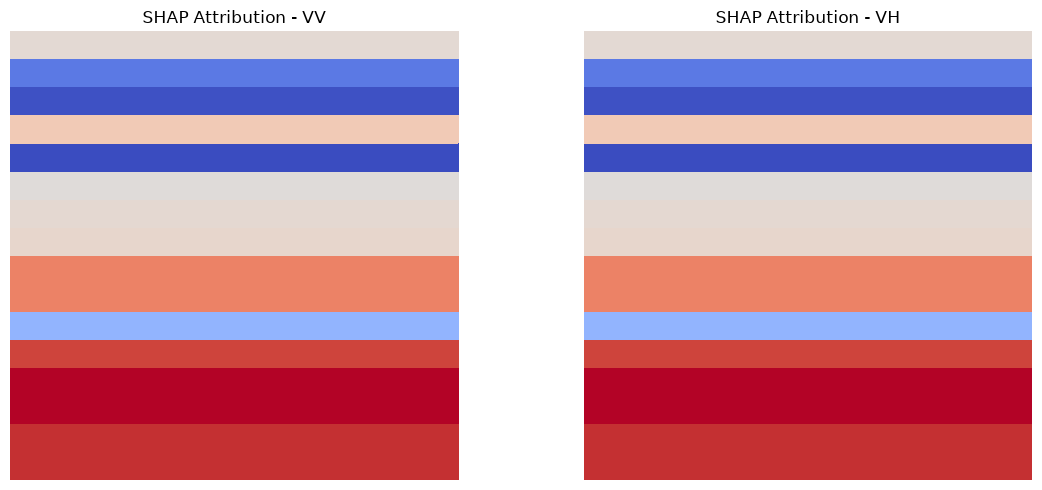

In [62]:
vv_shap = flood_shap[0]
vh_shap = flood_shap[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(
    vv_shap,
    cmap="coolwarm"
)
axes[0].set_title("SHAP Attribution - VV")
axes[0].axis("off")

im2 = axes[1].imshow(
    vh_shap,
    cmap="coolwarm"
)
axes[1].set_title("SHAP Attribution - VH")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 50. Creating the Spatial SHAP Attribution Map

The image-based SHAP explainer evaluates spatial regions of the Sentinel-1 image.

Because the image masker treats the VV and VH channels together when masking spatial regions, the resulting attribution should be interpreted as a spatial explanation rather than as independent VV and VH feature importance.

The absolute SHAP values across the two channels are therefore combined to create a single spatial attribution map.

This map represents the strength of the model's estimated contribution across different image regions.

The SHAP explanation can then be compared with the Grad-CAM heatmap and the ground-truth flood mask.

In [63]:
# Combine SHAP attribution across the two input channels

shap_spatial = np.mean(
    np.abs(flood_shap),
    axis=0
)

print("Spatial SHAP shape:", shap_spatial.shape)

print(
    "Minimum SHAP magnitude:",
    float(shap_spatial.min())
)

print(
    "Maximum SHAP magnitude:",
    float(shap_spatial.max())
)

Spatial SHAP shape: (128, 128)
Minimum SHAP magnitude: 3.507193468976766e-08
Maximum SHAP magnitude: 4.913217708235607e-07


## 51. Comparing Grad-CAM and SHAP

Grad-CAM and SHAP provide complementary explanations of the CNN prediction.

- **Grad-CAM** identifies spatial regions emphasized by the convolutional features.
- **SHAP** estimates the contribution of spatial regions relative to the selected background reference.

The two explanation maps are normalized independently for visualization so that their spatial patterns can be compared despite having different numerical scales.

The comparison is performed together with the ground-truth flood mask to examine whether both explanation methods highlight regions associated with annotated water.

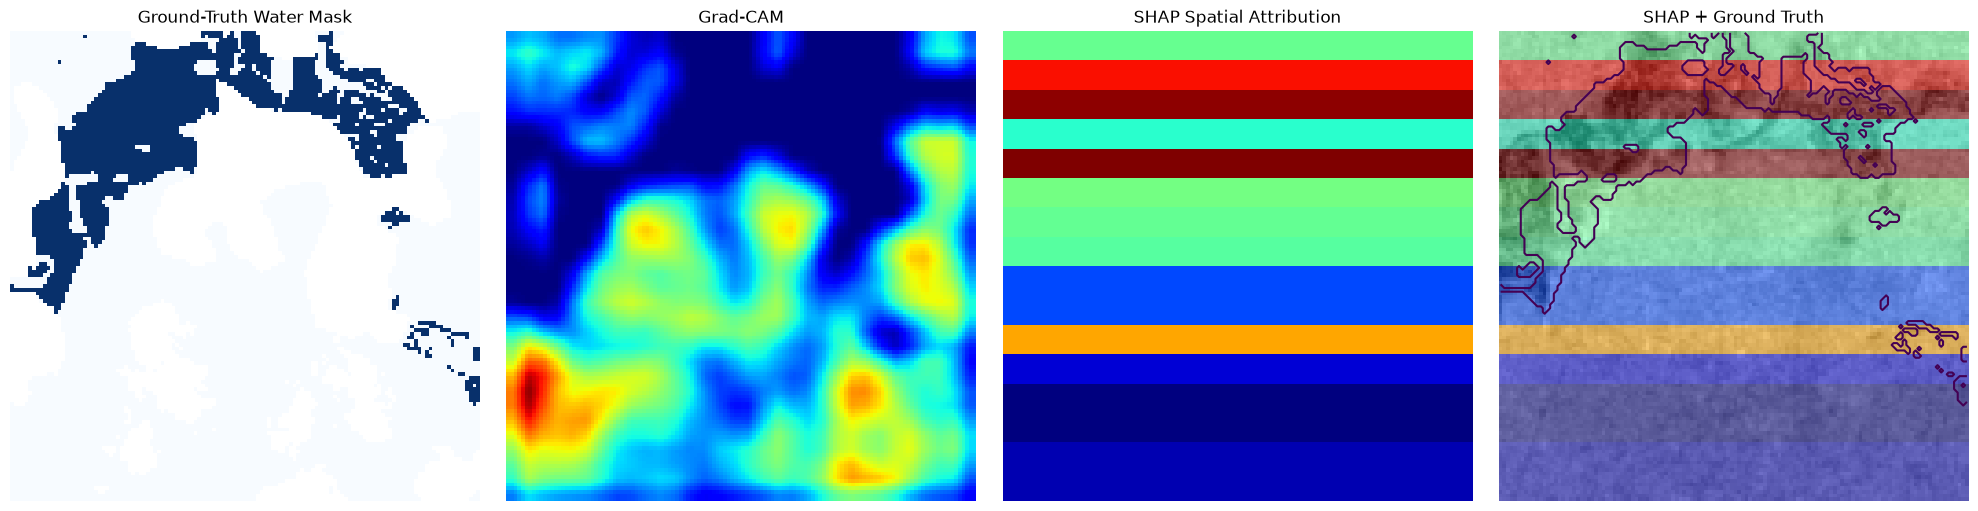

In [64]:
# Normalize SHAP values for visualization

shap_min = shap_spatial.min()
shap_max = shap_spatial.max()

if shap_max - shap_min > 0:
    shap_normalized = (
        (shap_spatial - shap_min)
        / (shap_max - shap_min)
    )
else:
    shap_normalized = np.zeros_like(shap_spatial)


fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 1. Ground Truth
axes[0].imshow(
    ground_truth_display,
    cmap="Blues",
    vmin=0,
    vmax=1
)
axes[0].set_title("Ground-Truth Water Mask")
axes[0].axis("off")

# 2. Grad-CAM
axes[1].imshow(
    cam_resized,
    cmap="jet",
    vmin=0,
    vmax=1
)
axes[1].set_title("Grad-CAM")
axes[1].axis("off")

# 3. SHAP
axes[2].imshow(
    shap_normalized,
    cmap="jet",
    vmin=0,
    vmax=1
)
axes[2].set_title("SHAP Spatial Attribution")
axes[2].axis("off")

# 4. SHAP + Ground Truth
axes[3].imshow(vv_image, cmap="gray")

axes[3].imshow(
    shap_normalized,
    cmap="jet",
    alpha=0.5,
    vmin=0,
    vmax=1
)

axes[3].contour(
    ground_truth == 1,
    levels=[0.5],
    linewidths=1.5
)

axes[3].set_title("SHAP + Ground Truth")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## 52. Inspecting the SHAP Attribution Structure

The previous SHAP visualization showed horizontal attribution patterns.

Before interpreting these patterns, the SHAP output will be inspected numerically.

This step checks:

- Whether the VV and VH attribution maps are identical.
- Whether the attribution varies meaningfully across rows and columns.
- Whether the spatial structure is suitable for comparison with the ground-truth flood mask.

This validation is important because SHAP explanations should not be interpreted spatially unless the attribution values are correctly aligned with the original image coordinates.

In [65]:
# Inspect SHAP attribution structure

print("Overall SHAP shape:", shap_values.values.shape)

print("\nVV and VH maps identical:",
      np.allclose(
          flood_shap[0],
          flood_shap[1]
      )
)

print("\nVV unique values:",
      len(np.unique(flood_shap[0]))
)

print("VH unique values:",
      len(np.unique(flood_shap[1]))
)

print("\nSpatial SHAP unique values:",
      len(np.unique(shap_spatial))
)

print("\nMean absolute attribution by row:")

row_means = np.mean(
    shap_spatial,
    axis=1
)

print(row_means[:10])

print("\nMean absolute attribution by column:")

column_means = np.mean(
    shap_spatial,
    axis=0
)

print(column_means[:10])

Overall SHAP shape: (1, 2, 128, 128, 2)

VV and VH maps identical: True

VV unique values: 13
VH unique values: 13

Spatial SHAP unique values: 13

Mean absolute attribution by row:
[2.51131496e-07 2.51131496e-07 2.51131496e-07 2.51131496e-07
 2.51131496e-07 2.51131496e-07 2.51131496e-07 2.51131496e-07
 4.41856173e-07 4.41856173e-07]

Mean absolute attribution by column:
[2.19099093e-07 2.19099093e-07 2.19099093e-07 2.19099093e-07
 2.19099093e-07 2.19099093e-07 2.19099093e-07 2.19099093e-07
 2.19099093e-07 2.19099093e-07]


In [66]:
# Inspect the refined SHAP explanation

flood_shap_fine = shap_values_fine.values[0, :, :, :, 1]

shap_spatial_fine = np.mean(
    np.abs(flood_shap_fine),
    axis=0
)

print("Refined SHAP shape:", flood_shap_fine.shape)

print(
    "VV and VH maps identical:",
    np.allclose(
        flood_shap_fine[0],
        flood_shap_fine[1]
    )
)

print(
    "VV unique values:",
    len(np.unique(flood_shap_fine[0]))
)

print(
    "VH unique values:",
    len(np.unique(flood_shap_fine[1]))
)

print(
    "Spatial SHAP unique values:",
    len(np.unique(shap_spatial_fine))
)

print(
    "Spatial SHAP range:",
    float(shap_spatial_fine.min()),
    "to",
    float(shap_spatial_fine.max())
)

Refined SHAP shape: (2, 128, 128)
VV and VH maps identical: True
VV unique values: 41
VH unique values: 41
Spatial SHAP unique values: 41
Spatial SHAP range: 6.175105227157474e-08 to 6.108239176683128e-07


## 53. Visualizing the Refined SHAP Explanation

The refined SHAP analysis provides a more detailed spatial attribution map than the initial SHAP experiment.

The refined explanation uses smaller spatial masking regions and a larger evaluation budget. This produces a greater number of distinct attribution values and allows the spatial contribution pattern to be examined in more detail.

For visualization, the SHAP attribution values are normalized to the range `0–1`. This normalization is performed only for visualization and does not change the underlying SHAP values.

The refined SHAP explanation will be compared with:

- The ground-truth flood mask.
- The Grad-CAM heatmap.
- The Sentinel-1 VV channel.

The comparison is intended to examine whether the regions highlighted by SHAP and Grad-CAM correspond to areas associated with the annotated flood regions.

Because the current SHAP image masker explains spatial regions jointly across the input channels, the resulting SHAP map is interpreted as a **combined spatial attribution**, rather than independent VV and VH feature importance.

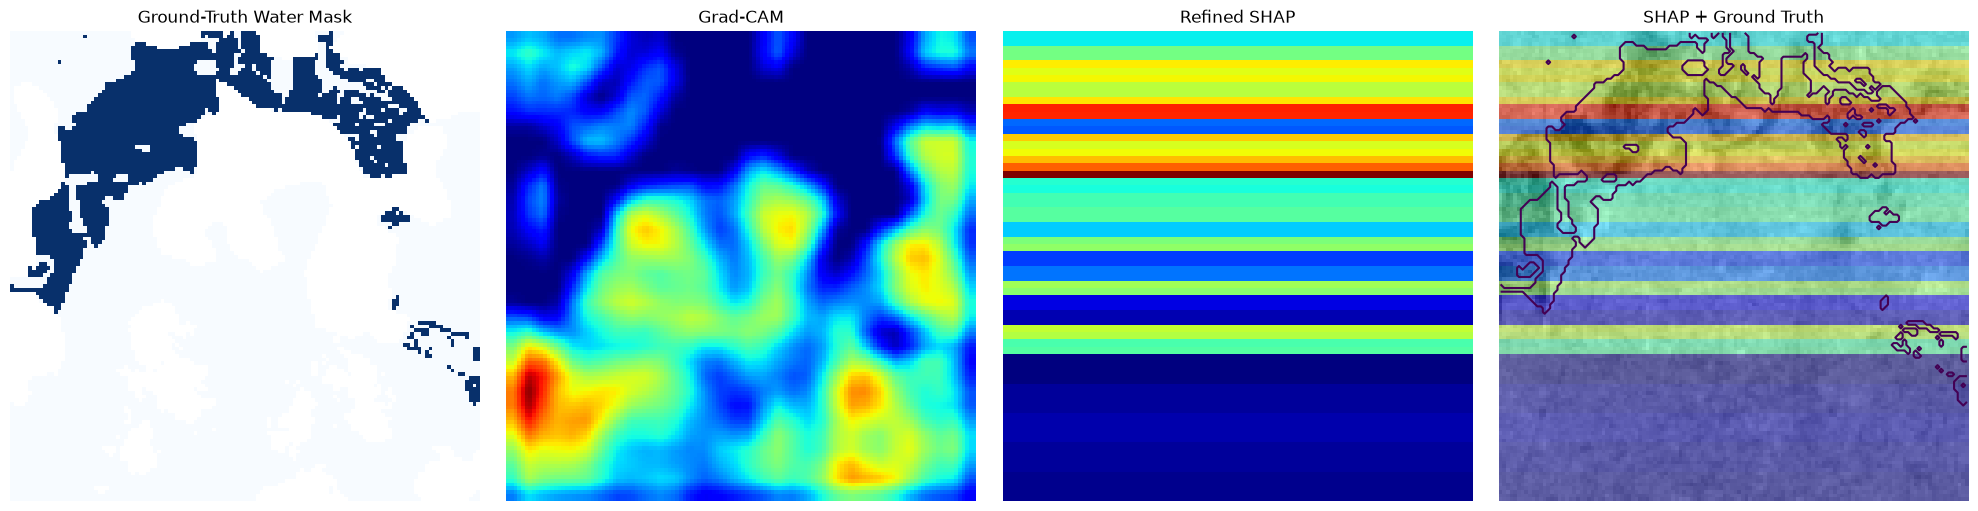

In [67]:
# Normalize refined SHAP values for visualization

shap_min = shap_spatial_fine.min()
shap_max = shap_spatial_fine.max()

if shap_max - shap_min > 0:
    shap_normalized_fine = (
        (shap_spatial_fine - shap_min)
        / (shap_max - shap_min)
    )
else:
    shap_normalized_fine = np.zeros_like(
        shap_spatial_fine
    )


fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

# Ground-truth water mask
axes[0].imshow(
    ground_truth_display,
    cmap="Blues",
    vmin=0,
    vmax=1
)

axes[0].set_title(
    "Ground-Truth Water Mask"
)

axes[0].axis("off")


# Grad-CAM
axes[1].imshow(
    cam_resized,
    cmap="jet",
    vmin=0,
    vmax=1
)

axes[1].set_title(
    "Grad-CAM"
)

axes[1].axis("off")


# Refined SHAP
axes[2].imshow(
    shap_normalized_fine,
    cmap="jet",
    vmin=0,
    vmax=1
)

axes[2].set_title(
    "Refined SHAP"
)

axes[2].axis("off")


# SHAP overlay with ground truth
axes[3].imshow(
    vv_image,
    cmap="gray"
)

axes[3].imshow(
    shap_normalized_fine,
    cmap="jet",
    alpha=0.5,
    vmin=0,
    vmax=1
)

axes[3].contour(
    ground_truth == 1,
    levels=[0.5],
    linewidths=1.5
)

axes[3].set_title(
    "SHAP + Ground Truth"
)

axes[3].axis("off")


plt.tight_layout()
plt.show()

## 54. Quantitative SHAP and Flood-Mask Overlap

The refined SHAP map provides a spatial attribution of the CNN's Flood prediction.

To obtain a simple quantitative comparison, the top 20% of SHAP attribution values will be classified as highly influential regions.

These regions will then be compared with the water pixels in the Sen1Floods11 ground-truth mask.

The overlap is calculated as:

SHAP Water Overlap =
(Highly Important SHAP Pixels ∩ Water Pixels)
/
Highly Important SHAP Pixels

This provides an exploratory measure of how much of the highest-attribution SHAP region coincides with annotated water.

The result should be interpreted together with the visualization and should not be considered a model accuracy metric or a standardized SHAP evaluation metric.

In [68]:
# Create a valid-pixel mask

valid_mask = ground_truth != -1

water_mask = ground_truth == 1


# Select the top 20% SHAP attribution values

shap_threshold = np.percentile(
    shap_spatial_fine[valid_mask],
    80
)

shap_high = (
    shap_spatial_fine >= shap_threshold
) & valid_mask


# Calculate overlap with annotated water

high_shap_pixels = np.sum(shap_high)

overlapping_water_pixels = np.sum(
    shap_high & water_mask
)


if high_shap_pixels > 0:

    shap_overlap_percentage = (
        overlapping_water_pixels
        / high_shap_pixels
    ) * 100

else:

    shap_overlap_percentage = 0


print(
    "SHAP threshold:",
    f"{shap_threshold:.10e}"
)

print(
    "Highly attributed pixels:",
    int(high_shap_pixels)
)

print(
    "Highly attributed pixels overlapping water:",
    int(overlapping_water_pixels)
)

print(
    "SHAP water overlap:",
    round(
        float(shap_overlap_percentage),
        2
    ),
    "%"
)

SHAP threshold: 3.7747486203e-07
Highly attributed pixels: 2211
Highly attributed pixels overlapping water: 1363
SHAP water overlap: 61.65 %


## 55. Comparing Grad-CAM and SHAP Explanations

Grad-CAM and SHAP provide complementary explanations of the CNN's Flood prediction.

For the selected test image:

- **Grad-CAM** identifies spatial regions that strongly influence the model's prediction through the activations and gradients of a convolutional layer.
- **SHAP** estimates the contribution of spatial input regions to the model's prediction relative to a background reference.

For an exploratory quantitative comparison, the top 20% of attribution values from each method were compared with the Sen1Floods11 ground-truth water mask.

The results for the selected test image are:

| XAI Method | Water Overlap |
|------------|---------------|
| Grad-CAM | 76.75% |
| SHAP | 61.65% |

The Grad-CAM and SHAP results are not directly equivalent measures because the two methods use different explanation mechanisms.

The overlap values are therefore used only to examine how the two explanations relate to the available ground-truth flood annotation.

These results are based on **one test image** and should not be interpreted as evidence that one XAI method is generally better than the other.

A larger evaluation across multiple test images would be required for a more reliable comparison.

In [72]:
print("Grad-CAM shape:", cam_resized.shape)
print("Ground-truth shape:", ground_truth.shape)

print("\nGrad-CAM range:")
print(
    "Min:",
    float(cam_resized.min())
)
print(
    "Max:",
    float(cam_resized.max())
)

print("\nGround-truth values:")
print(np.unique(ground_truth))

print("\nGround-truth pixel counts:")
print(
    "NoData (-1):",
    int(np.sum(ground_truth == -1))
)
print(
    "Non-Water (0):",
    int(np.sum(ground_truth == 0))
)
print(
    "Water (1):",
    int(np.sum(ground_truth == 1))
)


# Create valid and water masks

valid_mask = ground_truth != -1
water_mask = ground_truth == 1


# Calculate the top 20% Grad-CAM threshold

gradcam_threshold = np.percentile(
    cam_resized[valid_mask],
    80
)

print("\nGrad-CAM threshold:")
print(float(gradcam_threshold))


# Create high-activation mask

gradcam_high = (
    cam_resized >= gradcam_threshold
) & valid_mask


print("\nGrad-CAM high-activation pixels:")
print(int(np.sum(gradcam_high)))


print("\nOverlap pixels:")
print(
    int(
        np.sum(
            gradcam_high & water_mask
        )
    )
)

Grad-CAM shape: (128, 128)
Ground-truth shape: (128, 128)

Grad-CAM range:
Min: 0.0
Max: 0.979945719242096

Ground-truth values:
[-1  0  1]

Ground-truth pixel counts:
NoData (-1): 5657
Non-Water (0): 8254
Water (1): 2473

Grad-CAM threshold:
0.5188266038894653

Grad-CAM high-activation pixels:
2146

Overlap pixels:
0


## 56. Regenerating Grad-CAM for the Selected Test Sample

The Grad-CAM explanation and ground-truth mask must correspond to the same satellite image.

During the previous exploratory steps, different test-sample variables were used while developing the XAI analysis. To ensure that the comparison is spatially consistent, Grad-CAM will now be regenerated directly from the currently selected test image.

The procedure is:

1. Identify the selected test sample.
2. Retrieve its corresponding image tensor.
3. Generate a new Grad-CAM heatmap.
4. Resize the heatmap to `128 × 128`.
5. Use the corresponding ground-truth mask.
6. Recalculate the Grad-CAM and water-mask overlap.

This ensures that both the explanation and ground-truth annotation refer to exactly the same satellite image.

In [73]:
# Identify the selected test sample

original_index = test_indices[test_index]

selected_sample = all_samples[original_index]

print("Selected sample:")
print(selected_sample["filename"])

print(
    "Class:",
    selected_sample["class"]
)

print(
    "Water coverage:",
    selected_sample["water_percentage"],
    "%"
)


# Retrieve the corresponding test image

test_image = X_tensor[
    original_index
].unsqueeze(0).to(device)

print(
    "\nTest image shape:",
    test_image.shape
)


# Generate a fresh Grad-CAM

model.eval()

cam, predicted_class, output = generate_gradcam(
    model,
    test_image,
    target_layer
)


# Resize Grad-CAM to 128 × 128

cam_tensor = torch.tensor(
    cam
).unsqueeze(0).unsqueeze(0)

cam_resized = F.interpolate(
    cam_tensor,
    size=(128, 128),
    mode="bilinear",
    align_corners=False
)

cam_resized = (
    cam_resized
    .squeeze()
    .numpy()
)


print("\nActual class:", selected_sample["class_id"])

print(
    "Predicted class:",
    predicted_class
)

print(
    "Grad-CAM shape:",
    cam_resized.shape
)

print(
    "Grad-CAM range:",
    float(cam_resized.min()),
    "to",
    float(cam_resized.max())
)

Selected sample:
Ghana_319168_LabelHand.tif
Class: Flood
Water coverage: 23.03 %

Test image shape: torch.Size([1, 2, 128, 128])

Actual class: 1
Predicted class: 1
Grad-CAM shape: (128, 128)
Grad-CAM range: 0.0 to 0.979945719242096


## 57. Verifying Ground-Truth Spatial Alignment

Before calculating the Grad-CAM overlap, the ground-truth flood mask is checked against the selected Sentinel-1 image.

Both the satellite image and the ground-truth mask should represent the same spatial region and have the same dimensions.

The ground-truth mask is resized using nearest-neighbour resampling because the label values are categorical:

- `-1` → NoData
- `0` → Not Water
- `1` → Water

Nearest-neighbour resampling prevents the categorical label values from being altered during resizing.

This verification ensures that the Grad-CAM heatmap and ground-truth mask are spatially aligned before calculating their overlap.

In [74]:
# Reload the ground-truth mask for the selected sample

label_filename = selected_sample["filename"]

label_path = (
    Path("../data/sen1floods11/LabelHand")
    / label_filename
)

with rasterio.open(label_path) as src:

    ground_truth = src.read(
        1,
        out_shape=(128, 128),
        resampling=Resampling.nearest
    )


# Verify dimensions and label values

print("Selected label:", label_filename)

print(
    "Ground-truth shape:",
    ground_truth.shape
)

print(
    "Grad-CAM shape:",
    cam_resized.shape
)

print(
    "Ground-truth values:",
    np.unique(ground_truth)
)


# Create masks

valid_mask = ground_truth != -1

water_mask = ground_truth == 1


print("\nGround-truth pixel counts:")

print(
    "NoData:",
    int(np.sum(ground_truth == -1))
)

print(
    "Non-Water:",
    int(np.sum(ground_truth == 0))
)

print(
    "Water:",
    int(np.sum(ground_truth == 1))
)


# Check spatial dimensions

print("\nSpatial dimensions match:",
      cam_resized.shape == ground_truth.shape)

Selected label: Ghana_319168_LabelHand.tif
Ground-truth shape: (128, 128)
Grad-CAM shape: (128, 128)
Ground-truth values: [-1  0  1]

Ground-truth pixel counts:
NoData: 5657
Non-Water: 8254
Water: 2473

Spatial dimensions match: True


## 58. Recalculating the Grad-CAM and Flood-Mask Overlap

The Grad-CAM heatmap and ground-truth mask have now been regenerated and verified for the same test sample.

The top 20% of Grad-CAM activation values will be treated as highly activated regions.

These regions will be compared with the annotated water pixels in the ground-truth mask.

The overlap is calculated as:

Grad-CAM Water Overlap =
(Highly Activated Pixels ∩ Water Pixels)
/
Highly Activated Pixels

This provides an exploratory spatial comparison between the CNN's Grad-CAM explanation and the annotated flood regions.

The result applies only to the selected test image and is not a general evaluation metric for Grad-CAM.

In [75]:
# Create valid and water masks

valid_mask = ground_truth != -1
water_mask = ground_truth == 1


# Calculate the top 20% Grad-CAM threshold

gradcam_threshold = np.percentile(
    cam_resized[valid_mask],
    80
)


# Identify highly activated Grad-CAM regions

gradcam_high = (
    cam_resized >= gradcam_threshold
) & valid_mask


# Count pixels

gradcam_high_pixels = np.sum(
    gradcam_high
)

gradcam_water_pixels = np.sum(
    gradcam_high & water_mask
)


# Calculate overlap

if gradcam_high_pixels > 0:

    gradcam_overlap = (
        gradcam_water_pixels
        / gradcam_high_pixels
    ) * 100

else:

    gradcam_overlap = 0


print(
    "Grad-CAM threshold:",
    f"{gradcam_threshold:.4f}"
)

print(
    "Highly activated pixels:",
    int(gradcam_high_pixels)
)

print(
    "Highly activated pixels overlapping water:",
    int(gradcam_water_pixels)
)

print(
    "Grad-CAM water overlap:",
    round(
        float(gradcam_overlap),
        2
    ),
    "%"
)

Grad-CAM threshold: 0.5188
Highly activated pixels: 2146
Highly activated pixels overlapping water: 0
Grad-CAM water overlap: 0.0 %


## 59. Visual Verification of the Grad-CAM Explanation

The quantitative Grad-CAM overlap for the selected test image is `0.0%`.

Before interpreting this result, the Grad-CAM heatmap is visually compared with the ground-truth flood mask.

The visualization shows:

- **Sentinel-1 VV** → input image used by the CNN.
- **Ground Truth** → annotated water regions.
- **Grad-CAM** → regions receiving high model activation.
- **Grad-CAM + Ground Truth** → spatial comparison between model attention and annotated water.

This visual inspection is important because a low or zero overlap does not necessarily mean that the CNN has learned nothing useful. The model may be responding to other SAR characteristics, and the selected top-20% threshold captures only a portion of its spatial attribution.

The visualization will therefore be considered together with the quantitative overlap rather than interpreting the overlap value in isolation.

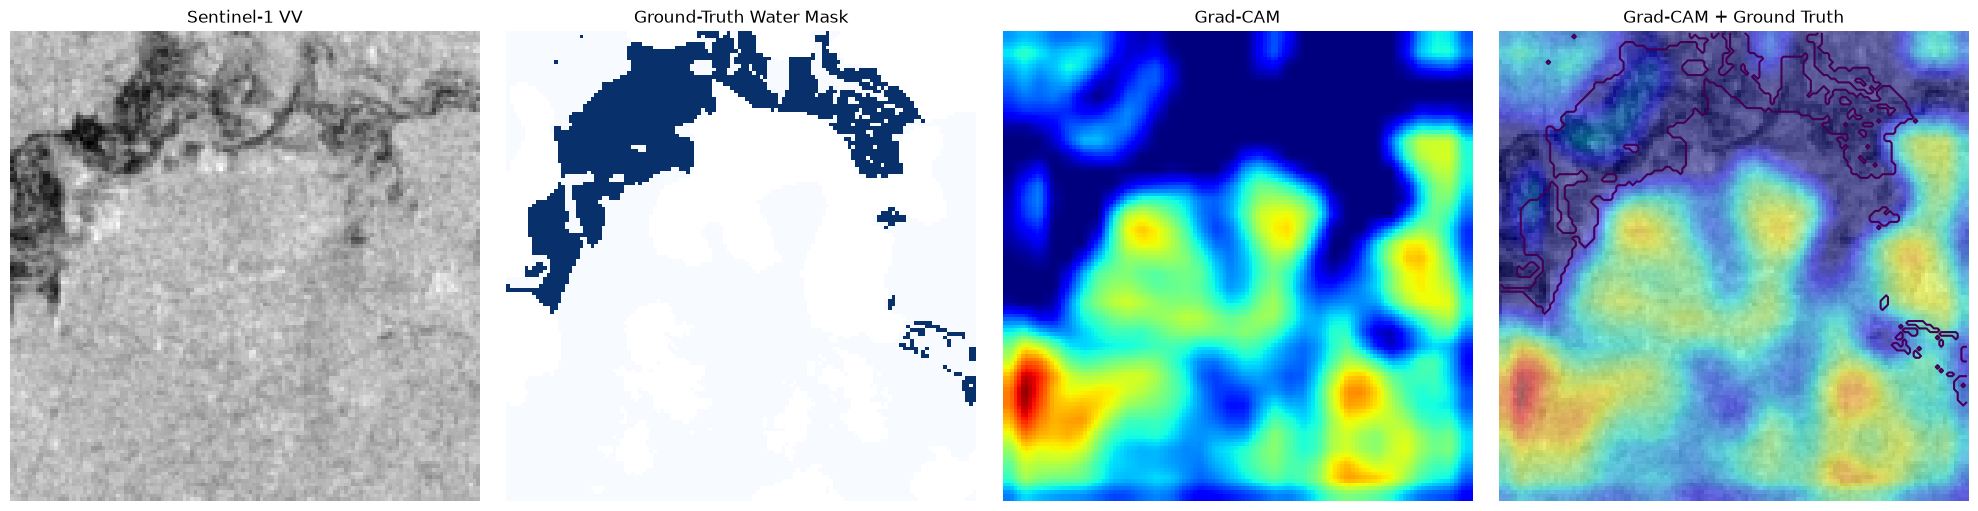

In [76]:
# Create a display version of the ground-truth mask

ground_truth_display = np.ma.masked_where(
    ground_truth == -1,
    ground_truth
)


fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)


# Sentinel-1 VV

axes[0].imshow(
    vv_image,
    cmap="gray"
)

axes[0].set_title(
    "Sentinel-1 VV"
)

axes[0].axis("off")


# Ground truth

axes[1].imshow(
    ground_truth_display,
    cmap="Blues",
    vmin=0,
    vmax=1
)

axes[1].set_title(
    "Ground-Truth Water Mask"
)

axes[1].axis("off")


# Grad-CAM

axes[2].imshow(
    cam_resized,
    cmap="jet",
    vmin=0,
    vmax=1
)

axes[2].set_title(
    "Grad-CAM"
)

axes[2].axis("off")


# Grad-CAM with ground truth contour

axes[3].imshow(
    vv_image,
    cmap="gray"
)

axes[3].imshow(
    cam_resized,
    cmap="jet",
    alpha=0.5,
    vmin=0,
    vmax=1
)

axes[3].contour(
    ground_truth == 1,
    levels=[0.5],
    linewidths=1.5
)

axes[3].set_title(
    "Grad-CAM + Ground Truth"
)

axes[3].axis("off")


plt.tight_layout()
plt.show()

## 60. Comparing Grad-CAM and SHAP Explanations

Grad-CAM and SHAP provide two different perspectives on the CNN's Flood prediction.

For the selected test image:

- **Grad-CAM** identifies spatial regions associated with the activation of the selected convolutional layer.
- **SHAP** estimates the contribution of masked spatial regions to the model's predicted class.

Using the top 20% attribution regions, the exploratory overlap with the ground-truth water mask is:

| Explanation Method | Water Overlap |
|--------------------|---------------|
| Grad-CAM | 0.00% |
| SHAP | 61.65% |

The results indicate that, for this particular test image and the selected overlap criterion, the highly attributed SHAP regions have greater spatial overlap with the annotated water regions than the highly activated Grad-CAM regions.

This should **not** be interpreted as evidence that SHAP is generally superior to Grad-CAM. The two methods measure different aspects of the model, and the comparison is based on only one test image and one experimental threshold.

The result instead demonstrates why multiple Explainable AI methods can provide complementary information when analyzing a deep learning model.

In [77]:
# Final exploratory XAI comparison

print("XAI Overlap Comparison")
print("-" * 30)

print(
    "Grad-CAM water overlap:",
    f"{gradcam_overlap:.2f}%"
)

print(
    "SHAP water overlap:",
    f"{shap_overlap_percentage:.2f}%"
)

print("\nTest sample:")
print(selected_sample["filename"])

print(
    "Actual class:",
    selected_sample["class"]
)

print(
    "Predicted class:",
    "Flood" if predicted_class == 1 else "Non-Flood"
)

XAI Overlap Comparison
------------------------------
Grad-CAM water overlap: 0.00%
SHAP water overlap: 61.65%

Test sample:
Ghana_319168_LabelHand.tif
Actual class: Flood
Predicted class: Flood


## 61. XAI Findings

The Explainable AI analysis was performed on a selected test image from the Sen1Floods11 dataset.

The CNN correctly classified the selected image as **Flood**.

Two XAI techniques were then applied:

### Grad-CAM

Grad-CAM was used to identify spatial regions associated with the CNN's prediction.

For the selected image, the top 20% of Grad-CAM activation regions showed:

- Highly activated pixels: 2,146
- Pixels overlapping annotated water: 0
- Exploratory water overlap: 0.00%

This indicates that the regions receiving the strongest Grad-CAM activation did not overlap with the annotated water regions under the selected threshold for this test image.

### SHAP

SHAP was used to estimate the contribution of spatial regions to the Flood prediction.

For the selected image:

- Highly attributed pixels: 2,211
- Pixels overlapping annotated water: 1,363
- Exploratory water overlap: 61.65%

The SHAP explanation therefore showed a greater spatial overlap with the annotated water regions for this particular test image.

These results demonstrate that different XAI techniques can highlight different aspects of the same model prediction.

## 62. Limitations of the Current Experiment

The current analysis is an exploratory proof-of-concept rather than a complete flood-detection study.

The main limitations are:

1. **Small dataset**

   Only 24 selected satellite images were used, with 19 images for training and 5 for testing.

2. **Derived classification labels**

   Sen1Floods11 is fundamentally a pixel-level flood segmentation dataset. The image-level Flood and Non-Flood labels used here were created using an experimental 5% water-coverage threshold.

3. **Small test set**

   The CNN was evaluated on only five test images. Therefore, the classification metrics cannot be interpreted as representative of performance on the complete dataset.

4. **Limited XAI evaluation**

   The Grad-CAM and SHAP overlap calculations were performed on one selected test image using a top-20% attribution threshold.

5. **SHAP interpretation**

   The current image masker explains spatial regions jointly across the VV and VH channels. Therefore, the SHAP results should be interpreted as a combined spatial attribution rather than independent channel importance.

6. **Proof-of-concept model**

   The CNN was intentionally kept small to demonstrate the complete workflow. A larger dataset and stronger segmentation architecture would be required for a more rigorous study.

These limitations should be addressed in future experiments before drawing broader conclusions about flood detection or Explainable AI performance.

## 63. Conclusion and Future Work

This notebook demonstrated an initial Explainable AI pipeline for satellite-based flood analysis using the Sen1Floods11 dataset.

The implemented workflow was:

Satellite Imagery
→ Sentinel-1 VV/VH preprocessing
→ CNN Flood Classification
→ Model Prediction
→ Grad-CAM
→ SHAP
→ Comparison with Ground-Truth Flood Mask

The CNN successfully performed the initial image-level classification task.

Grad-CAM provided a spatial visualization of the regions associated with the CNN's prediction, while SHAP provided a spatial attribution of the input regions contributing to the prediction.

For the selected test image, the two XAI methods produced different spatial explanations. The exploratory overlap with the ground-truth water mask was 0.00% for Grad-CAM and 61.65% for SHAP.

These results should not be interpreted as a general comparison between the two XAI methods because the analysis was performed on a very small dataset and a single selected test image.

### Future Work

The next stage of the research could include:

- Expanding the dataset to include more Sen1Floods11 samples.
- Using the original pixel-level annotations directly.
- Developing a U-Net or similar segmentation model.
- Evaluating XAI explanations across multiple test images.
- Investigating Grad-CAM and SHAP attributions more systematically.
- Comparing explanations with ground-truth flood regions using multiple quantitative measures.
- Studying the contribution of Sentinel-1 VV and VH channels separately.
- Extending the analysis to additional flood events and geographical regions.

Overall, this experiment establishes a practical starting point for studying Explainable AI in satellite-based flood analysis.